# belief eye neural analysis


## imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [3]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA

In [4]:
# misc
import pickle
from collections import defaultdict

In [5]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

In [6]:
df = pd.read_pickle(resdir/'0414_m51df.pkl')
len(df)
df=df[df.session==41]

In [7]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [8]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


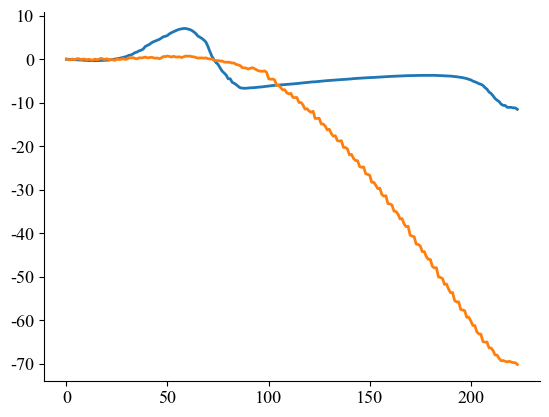

In [61]:
row=df.iloc[2]
plt.plot(row.bmx/17)
plt.plot(row.mx)

In [9]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [10]:
df.columns

Index(['trial', 'session', 'fullon', 'density', 'eye_hori', 'eye_vert',
       'ff_hori', 'ff_vert', 'fx', 'fy', 'mx', 'my', 'mv', 'mw', 'PPC',
       'PPC_var', 'PFC', 'PFC_var', 'MST', 'MST_var', 'error', 'error_sign',
       'target_angle', 'target_distance', 'state', 'action', 'task',
       'likelihood', 'belief', 'rawcov', 'bmx', 'bmy', 'heading',
       'belief_heading', 'timer', 'countdown', 'belief_ff_hori',
       'belief_ff_vert', 'angle_from_start', 'belief_angle_from_start',
       'relcov', 'state_error', 'belief_error', 'time_ratio'],
      dtype='object')

In [11]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [12]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

# work

In [13]:
# when belief eye are different
'''seems the eye fixes and belief moves at begining of trial (from time ratio plots)
why? could be animal is not rational (did not pay attention) and irc still trys to explain. (irc assumes animla always see the target at begining)
or could be animal eye fix, moves and still thinking/update the belief.
evidence: mk moves. but eye does not.
    if pay attention, mk eye shoudl activly searching


if mk not paying attention. mk dos not see the target. those trials will have larger error and miss rate.
if mk is thinking, trials should have simlar error rate. mk see the target.
'''


'seems the eye fixes and belief moves at begining of trial (from time ratio plots)\nwhy? could be animal is not rational (did not pay attention) and irc still trys to explain. (irc assumes animla always see the target at begining)\nor could be animal eye fix, moves and still thinking/update the belief.\nevidence: mk moves. but eye does not.\n    if pay attention, mk eye shoudl activly searching\n\n\nif mk not paying attention. mk dos not see the target. those trials will have larger error and miss rate.\nif mk is thinking, trials should have simlar error rate. mk see the target.\n'

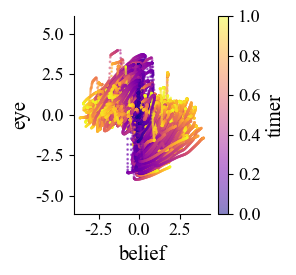

In [14]:
'''
time ratio shows, the x is early on in trials. either strong correlation or no corr. later, corerlation become weak.
'''
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())
    timer=np.concatenate(sessdf.time_ratio.to_numpy())
    
    related_taskvar, mask = process([state, belief, eye], returnmask=True)
    [state, belief, eye]=zip(*related_taskvar)
    timer=timer[mask]
    # maskvar=np.array(eye)
    # mask=(maskvar<=-2)|(maskvar>2)
    # print(len(eye))
    # state, belief, eye=[np.array(a)[mask] for a in [state, belief, eye]]
    # print(eye.shape)


    fig, ax = plt.subplots(figsize=(3,3))
    c=ax.scatter(belief,eye, c=timer, cmap='plasma', s=1, alpha=0.5)
    plt.colorbar(c, label='timer')

    # slope=plot_best_fit(belief,eye, ax)
    # print(slope)
    # r,_=pearsonr(belief,eye)
    # ax.set_title(f'Pearson r: {r:.2f}')

    ax.set_xlabel(f'belief')
    ax.set_ylabel(f'eye')
    ax.axis('equal')

    plt.tight_layout()

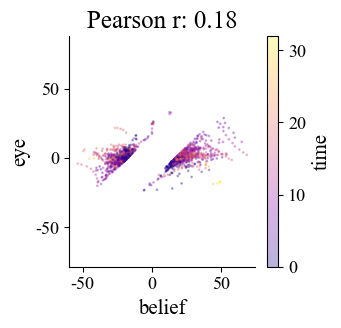

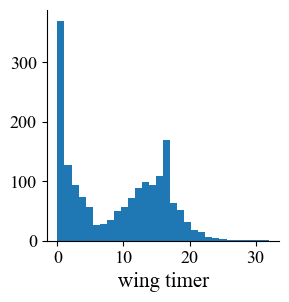

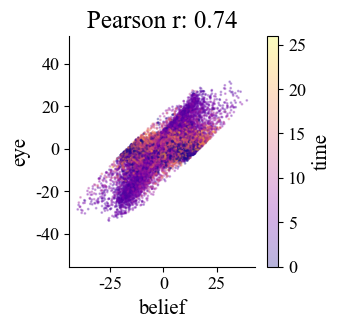

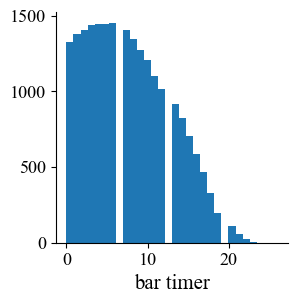

In [30]:
# when belief eye are different (try to seperate the x)
'''idea, there is a x when plot belief-eye scatter. 
can seperate the x by fitting the main bar (smaller err)
small wing has larger error
'''
from sklearn.linear_model import LinearRegression

aa,bb,cc=np.stack(timedf.belief.to_numpy()),np.stack(timedf.eye.to_numpy()),timedf.timer.to_numpy()
thisx,thisy,thisc=aa,bb,cc
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
thisxname, thisyname, thiscname='belief', 'eye', 'time'

# mask the wing by eye and fit.
mask=(thisy<=-11)|(thisy>11)
# mask=(thisy>-11)&(thisy<11)
thisx,thisy,thisc=[a[mask] for a in [thisx,thisy,thisc]]
model = LinearRegression()
model.fit(thisx.reshape(-1,1),thisy.reshape(-1,1))

# fitting ---------------
# fig, ax = plt.subplots(figsize=(3,3))
# ax.scatter(thisx, thisy,c=thisc, s=1, alpha=0.3)
# slope=plot_best_fit(thisx, thisy, ax)
# # print(slope)
# r,_=pearsonr(thisx, thisy)
# ax.set_xlabel(f'belief')
# ax.set_ylabel(f'eye')
# ax.axis('equal')
# ax.set_title(f'Pearson r: {r:.2f}')


# bar 1 -----------------
thisx,thisy,thisc=aa,bb,cc
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
thispred=model.predict(thisx.reshape(-1,1)).reshape(-1)
err=np.array(normalize_z((thisy-thispred)**2))
mask=err>1
thispred,thisy, thisc=thispred[mask],thisy[mask], thisc[mask]

fig, ax = plt.subplots(figsize=(3,3))
c=ax.scatter(thispred,thisy, c=thisc, cmap='plasma', s=1, alpha=0.3)
plt.colorbar(c, label=f'{thiscname}')
# slope=plot_best_fit(thispred,thisy, ax)
r,_=pearsonr(thispred,thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.set_xlabel(f'{thisxname}')
ax.set_ylabel(f'{thisyname}')
ax.axis('equal')
plt.show()

fig, ax = plt.subplots(figsize=(3,3))
plt.hist(thisc, bins=30)
plt.xlabel('wing timer')
plt.show()

# bar 2 -----------------
thisx,thisy,thisc=aa,bb,cc
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
thispred=model.predict(thisx.reshape(-1,1)).reshape(-1)
err=np.array(normalize_z((thisy-thispred)**2))
mask=err<1
thispred,thisy, thisc=thispred[mask],thisy[mask], thisc[mask]

fig, ax = plt.subplots(figsize=(3,3))
c=ax.scatter(thispred,thisy, c=thisc, cmap='plasma', s=1, alpha=0.3)
plt.colorbar(c, label=f'{thiscname}')
# slope=plot_best_fit(thispred,thisy, ax)
r,_=pearsonr(thispred,thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.set_xlabel(f'{thisxname}')
ax.set_ylabel(f'{thisyname}')
ax.axis('equal')
plt.show()

fig, ax = plt.subplots(figsize=(3,3))
plt.hist(thisc, bins=30)
plt.xlabel('bar timer')
plt.show()



23140
(1862,)


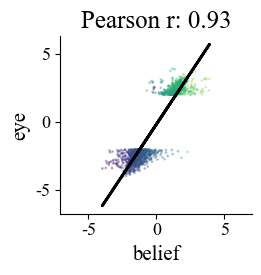

In [31]:


for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())
    
    related_taskvar = process([state, belief, eye])
    [state, belief, eye]=zip(*related_taskvar)
    
    maskvar=np.array(eye)
    mask=(maskvar<=-2)|(maskvar>2)
    print(len(eye))
    state, belief, eye=[np.array(a)[mask] for a in [state, belief, eye]]
    print(eye.shape)
    # related_taskvar = process([state, belief, eye])


    thisx, thisy, thisc=belief,eye,state
    
    fig, ax = plt.subplots(figsize=(3,3))
    ax.scatter(thisx, thisy,c=thisc, s=1, alpha=0.3)

    slope=plot_best_fit(thisx, thisy, ax)
    # print(slope)
    r,_=pearsonr(thisx, thisy)

    ax.set_xlabel(f'belief')
    ax.set_ylabel(f'eye')
    ax.axis('equal')
    ax.set_title(f'Pearson r: {r:.2f}')

    plt.tight_layout()

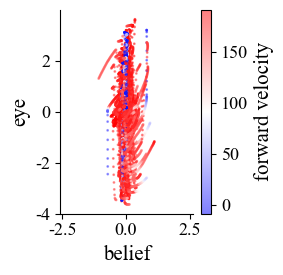

In [15]:
'''
actions at when belief eye differ
no pattern.
'''
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())
    timer=np.concatenate(sessdf.time_ratio.to_numpy())
    mv=np.concatenate(sessdf.mv.to_numpy())
    mw=np.concatenate(sessdf.mw.to_numpy())
    
    related_taskvar, mask = process([state, belief, eye], returnmask=True)
    [state, belief, eye]=zip(*related_taskvar)
    timer=timer[mask]
    mv=mv[mask]
    mw=mw[mask]

    colorvar=mv
    maskvar=np.array(timer)
    mask=(maskvar<=0.2)&(maskvar>0)
    belief, eye, colorvar = [np.array(a)[mask] for a in [belief, eye, colorvar]]

    fig, ax = plt.subplots(figsize=(3,3))
    c=ax.scatter(belief,eye, c=colorvar, cmap='bwr', s=1, alpha=0.5)
    plt.colorbar(c, label='forward velocity')

    # slope=plot_best_fit(belief,eye, ax)
    # print(slope)
    # r,_=pearsonr(belief,eye)
    # ax.set_title(f'Pearson r: {r:.2f}')

    ax.set_xlabel(f'belief')
    ax.set_ylabel(f'eye')
    ax.axis('equal')

    plt.tight_layout()

# plots

In [36]:
belief_error

array([3718.42629005, 1939.81130211, 1293.62946101, ..., 4840.91103135,
        863.42627117, 4163.31154893])

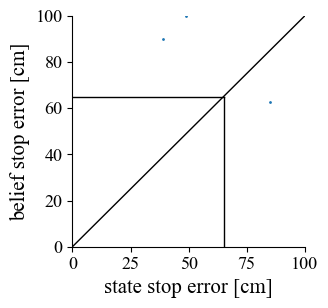

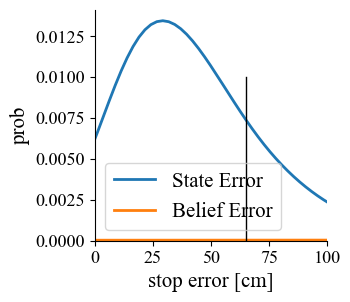

In [42]:
# state vs belief stop error
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())

    fig, ax = plt.subplots(1,1, figsize=(3,3))
    ax.scatter(state_error,belief_error, s=1, alpha=1)
    ax.plot([0,222],[0,222],color='black', linewidth=1)
    ax.plot([0,65],[65,65],color='black', linewidth=1)
    ax.plot([65,65],[65,0],color='black', linewidth=1)
    ax.set_xlim(0,100)
    ax.set_ylim(0,100)
    ax.set_xlabel('state stop error [cm]')
    ax.set_ylabel('belief stop error [cm]')
    # ax.axis('equal')
    quickspine(ax)
    fig.show()

    fig, ax = plt.subplots(1,1, figsize=(3,3))
    sns.kdeplot(state_error, ax=ax, label='State Error',bw=0.5)
    sns.kdeplot(belief_error, ax=ax, label='Belief Error',bw=0.5)
    ax.plot([65,65],[0.01,0],color='black', linewidth=1)
    ax.set_xlabel('stop error [cm]')
    ax.set_ylabel('prob')
    ax.set_xlim(0,100)
    ax.legend()
    quickspine(ax)
    fig.show()

  

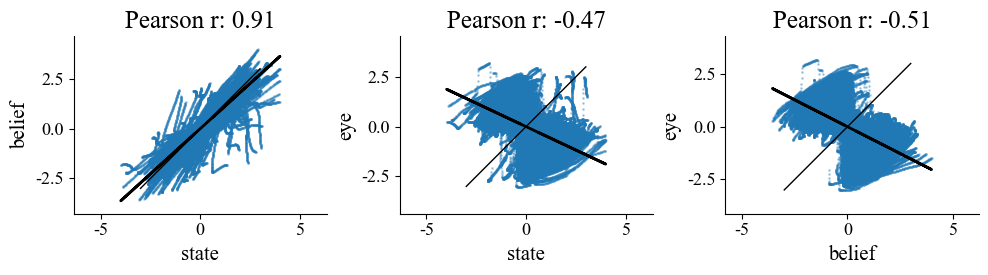

In [17]:
# state, eye, belief corr (masked by time ratio)

for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())
    
    maskvar=np.concatenate(sessdf.time_ratio.to_numpy())
    mask=(maskvar<=0.6) & (maskvar>0.2)
    [state, belief, eye]=[a[mask] for a in [state, belief, eye]]
    related_taskvar = process([state, belief, eye])
    
    fig, axs = plt.subplots(1,3, figsize=(10,3))
    names=['state','belief','eye']
    k=0
    for i in range(3):
        for j in range(i+1,3):
            axs[k].scatter(related_taskvar[:,i], related_taskvar[:,j], s=1, alpha=0.3)
            axs[k].plot([-3,3],[-3,3],color='black', linewidth=1)
            
            plot_best_fit(related_taskvar[:,i], related_taskvar[:,j], axs[k])
            # quickallspine(ax)
            ax.axis('equal')
            r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,j])

            axs[k].set_xlabel(f'{names[i]}')
            axs[k].set_ylabel(f'{names[j]}')
            axs[k].axis('equal')
            axs[k].set_title(f'Pearson r: {r:.2f}')
            k+=1
    plt.tight_layout()

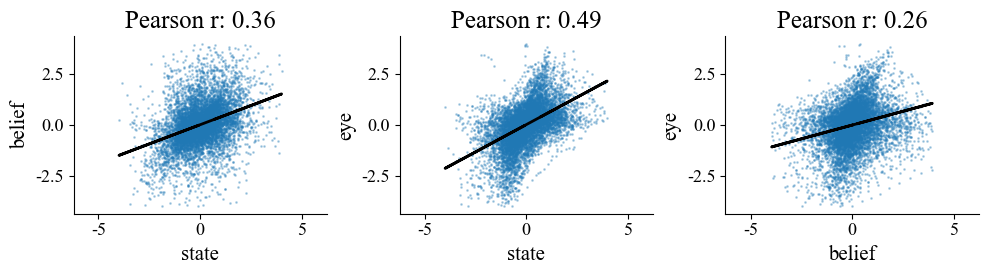

In [35]:
# state, eye, belief corr (masked by time)

for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())
    
    markvar=np.concatenate(sessdf.timer.to_numpy())
    mask=(markvar>7)
    [state, belief, eye]=[a[mask] for a in [state, belief, eye]]

    related_taskvar = process([state, belief, eye])
    
    fig, axs = plt.subplots(1,3, figsize=(10,3))
    names=['state','belief','eye']
    k=0
    for i in range(3):
        for j in range(i+1,3):
            axs[k].scatter(related_taskvar[:,i], related_taskvar[:,j], s=1, alpha=0.3)
            # axs[k].plot([-3,3],[-3,3],color='black', linewidth=1)
            
            plot_best_fit(related_taskvar[:,i], related_taskvar[:,j], axs[k])
            # quickallspine(ax)
            ax.axis('equal')
            r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,j])

            axs[k].set_xlabel(f'{names[i]}')
            axs[k].set_ylabel(f'{names[j]}')
            axs[k].axis('equal')
            axs[k].set_title(f'Pearson r: {r:.2f}')
            k+=1
    plt.tight_layout()

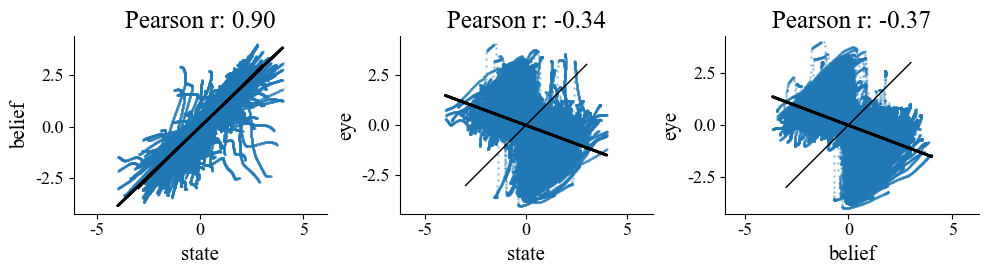

In [18]:
# state, eye, belief corr, unmasked
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
    belief=np.concatenate(sessdf.ff_hori.to_numpy())
    eye=np.concatenate(sessdf.eye_hori.to_numpy())

    related_taskvar = process([state, belief, eye])
    
    fig, axs = plt.subplots(1,3, figsize=(10,3))
    names=['state','belief','eye']
    k=0
    for i in range(3):
        for j in range(i+1,3):
            axs[k].scatter(related_taskvar[:,i], related_taskvar[:,j], s=1, alpha=0.3)
            axs[k].plot([-3,3],[-3,3],color='black', linewidth=1)
            s=plot_best_fit(related_taskvar[:,i], related_taskvar[:,j], axs[k])
            r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,j])
            axs[k].set_title(f'Pearson r: {r:.2f}')
            axs[k].set_xlabel(f'{names[i]}')
            axs[k].set_ylabel(f'{names[j]}')
            axs[k].axis('equal')
            k+=1
    plt.tight_layout()

In [37]:
# # overhead stops subtraction
# state_error=(df.state_error.to_numpy())
# belief_error=(df.belief_error.to_numpy())

# fig, ax = plt.subplots(1,1, figsize=(4,4))
# overheadbase(ax)
# bsdiff=[a-b for a,b in zip(belief_error, state_error)]
# target_location=np.array([(x[0],y[0]) for x,y in zip(df.fx.to_list(), df.fy.to_list())])

# vm=np.max(np.abs(bsdiff))
# cax=ax.scatter(target_location[:,0], target_location[:,1], s=5, c=bsdiff, cmap='bwr', vmin=-vm, vmax=vm)
# cbar = fig.colorbar(cax,shrink=0.6, label='belief reward - state reward')


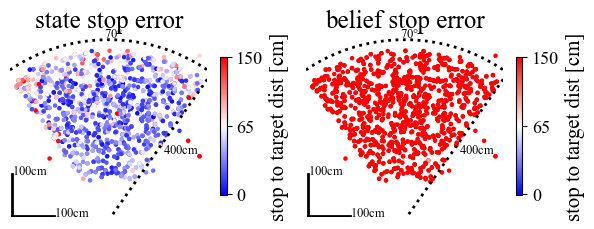

In [19]:
# overhead stops
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())
    
    target_location=np.array([(x[0],y[0]) for x,y in zip(sessdf.fx.to_list(), sessdf.fy.to_list())])
    norm=getcbarnorm(0, 65, 150)

    fig, axs = plt.subplots(1,2, figsize=(7,3))
    ax=axs[0]
    overheadbase(ax)
    cax=ax.scatter(target_location[:,0], target_location[:,1], s=5, c=state_error, cmap='bwr', norm=norm)
    cbar = fig.colorbar(cax,shrink=0.6, label='stop to target dist [cm]')
    cbar.ax.yaxis.set_ticks([1,65,150])
    cbar.ax.yaxis.set_ticklabels([0,65,150])
    ax.set_title('state stop error')

    ax=axs[1]
    overheadbase(ax)
    cax=ax.scatter(target_location[:,0], target_location[:,1], s=5, c=belief_error, cmap='bwr', norm=norm)
    cbar = fig.colorbar(cax,shrink=0.6, label='stop to target dist [cm]')
    cbar.ax.yaxis.set_ticks([1,65,150])
    cbar.ax.yaxis.set_ticklabels([0,65,150])
    ax.set_title('belief stop error')

    plt.show()

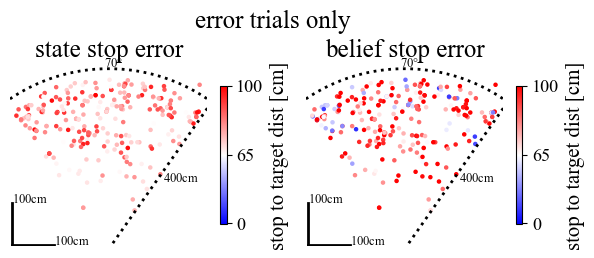

In [39]:
# overhead stops for error trials
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())
    
    target_location=np.array([(x[0],y[0]) for x,y in zip(sessdf.fx.to_list(), sessdf.fy.to_list())])
    norm=getcbarnorm(0, 65, 100)

    fig, axs = plt.subplots(1,2, figsize=(7,3))
    ax=axs[0]
    overheadbase(ax)
    mask=(state_error>65) & (state_error<100)
    cax=ax.scatter(target_location[mask,0], target_location[mask,1], s=5, c=state_error[mask], cmap='bwr', norm=norm)
    cbar = fig.colorbar(cax,shrink=0.6, label='stop to target dist [cm]')
    cbar.ax.yaxis.set_ticks([1,65,100])
    cbar.ax.yaxis.set_ticklabels([0,65,100])
    ax.set_title('state stop error')

    ax=axs[1]
    overheadbase(ax)
    # mask= (belief_error>65) & (belief_error<100)
    cax=ax.scatter(target_location[mask,0], target_location[mask,1], s=5, c=belief_error[mask], cmap='bwr', norm=norm)
    cbar = fig.colorbar(cax,shrink=0.6, label='stop to target dist [cm]')
    cbar.ax.yaxis.set_ticks([1,65,100])
    cbar.ax.yaxis.set_ticklabels([0,65,100])
    ax.set_title('belief stop error')
    fig.suptitle('error trials only')
    plt.show()

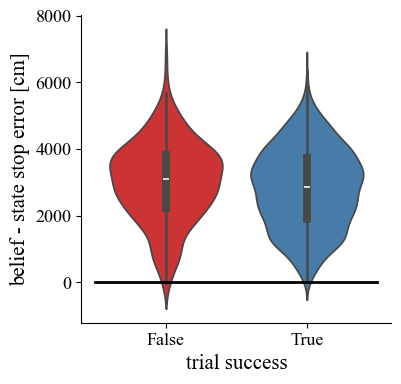


    above zero line, belief stop error > state stop error.
    below zero line, belief stop error < state stop error.
    


In [20]:
# radial err vs belief explaining corr
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())
    
    x,y=belief_error-state_error, state_error
    plt.figure(figsize=(4, 4))
    data = {
        "trial success": y<65,
        "belief explaining power": x,
    }
    sns.violinplot(x="trial success", y="belief explaining power", data=data, palette="Set1")
    plt.xlabel("trial success")
    plt.ylabel("belief - state stop error [cm]")
    plt.plot([-0.5,1.5],[0,0], color='k')
    plt.show()
    
print('''
    above zero line, belief stop error > state stop error.
    below zero line, belief stop error < state stop error.
    ''')

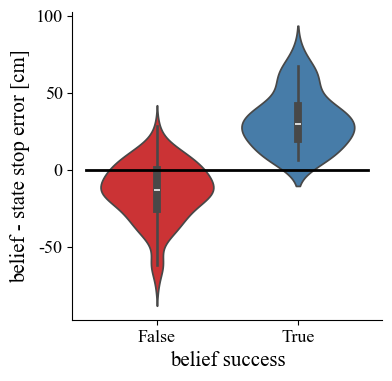


    above zero line, belief stop error > state stop error.
    below zero line, belief stop error < state stop error.
    for the trials mk think he hits, belief error > state error
    for the trials mk think he missed, belief error < state error.
    


In [41]:
# radial err vs belief explaining corr, error trails
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())
    
    mask=(state_error>65) & (state_error<100)
    x,y=state_error[mask]-belief_error[mask], belief_error[mask]
    plt.figure(figsize=(4, 4))
    data = {
        "trial success": y<65,
        "belief explaining power": x,
    }
    sns.violinplot(x="trial success", y="belief explaining power", data=data, palette="Set1")
    plt.xlabel("belief success")
    plt.ylabel("belief - state stop error [cm]")
    plt.plot([-0.5,1.5],[0,0], color='k')
    plt.show()
print('''
    above zero line, belief stop error > state stop error.
    below zero line, belief stop error < state stop error.
    for the trials mk think he hits, belief error > state error
    for the trials mk think he missed, belief error < state error.
    ''')

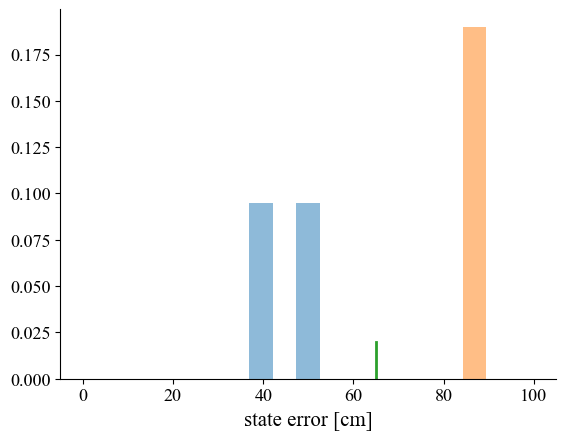

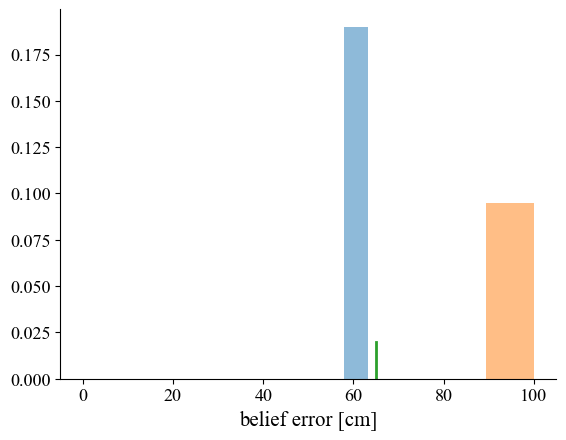

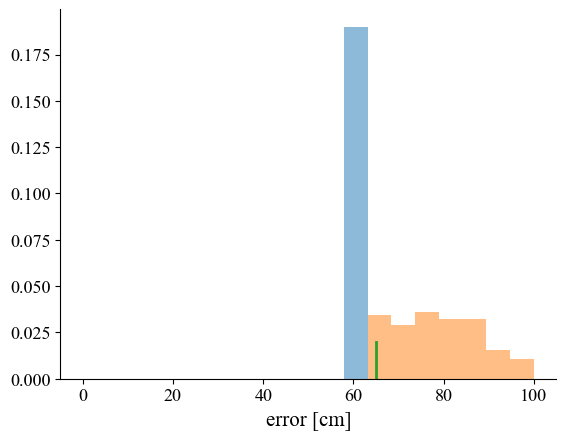

In [21]:
state_error=(df.state_error.to_numpy())
belief_error=(df.belief_error.to_numpy())

statefail=(state_error>65) & (state_error<100)
statehit=(state_error<=65) 
belieffail=(belief_error>65) & (belief_error<100)
beliefhit=(belief_error<=65) 

# plt.hist(state_error[statefail], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
# plt.hist(state_error[statehit], bins=np.linspace(0,100,20), alpha=0.5, density=True) 

plt.hist(state_error[belieffail], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.hist(state_error[beliefhit], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.plot([65,65],[0,0.02])
plt.xlabel('state error [cm]')
plt.show()

plt.hist(belief_error[statefail], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.hist(belief_error[statehit], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.xlabel('belief error [cm]')
plt.plot([65,65],[0,0.02])
plt.show()

plt.hist(belief_error[statefail], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.hist(state_error[statefail], bins=np.linspace(0,100,20), alpha=0.5, density=True) 
plt.xlabel('error [cm]')
plt.plot([65,65],[0,0.02])

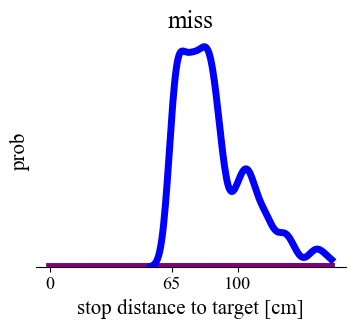

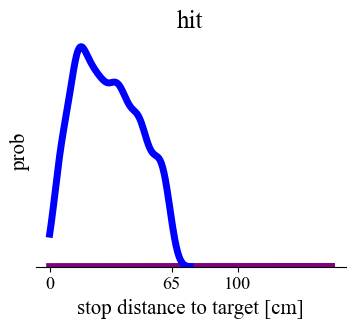

In [22]:
# histogram of distribution
for session in sorted(df.session.unique()):
    sessdf=df[df.session==session]

    state_error=(sessdf.state_error.to_numpy())
    belief_error=(sessdf.belief_error.to_numpy())

    statefail=(state_error>65) & (state_error<150)
    statehit=(state_error<=65) 
    belieffail=(belief_error>65) & (belief_error<150)
    beliefhit=(belief_error<=65) 

    fig, ax = plt.subplots(figsize=(4,3))
    # ax.hist(belief_error[statefail], bins=np.linspace(0,150,30), alpha=0.5, density=True) 
    # ax.hist(state_error[statefail], bins=np.linspace(0,150,30), alpha=0.5, density=True) 
    sns.kdeplot(belief_error[statefail],bw=0.2, clip=(0,150), linewidth=5, color=belief_color)
    sns.kdeplot(state_error[statefail],bw=0.2, clip=(0,150), linewidth=5, color=state_color)
    plt.xlabel('stop distance to target [cm]')
    plt.xticks([0,65,100])
    ax.yaxis.set_ticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('prob')
    # plt.xlim(0,100)
    ax.set_title('miss')
    plt.show()

    fig, ax = plt.subplots(figsize=(4,3))
    sns.kdeplot(belief_error[statehit],bw=0.2, clip=(0,150), linewidth=5, color=belief_color)
    sns.kdeplot(state_error[statehit],bw=0.2, clip=(0,150), linewidth=5, color=state_color)
    plt.xlabel('stop distance to target [cm]')
    plt.xticks([0,65,100])
    ax.yaxis.set_ticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('prob')
    ax.set_title('hit')
    # plt.xlim(0,100)
    plt.show()



In [23]:
# table (todo, roc)
state_error=(df.state_error.to_numpy())
belief_error=(df.belief_error.to_numpy())

statefail=(state_error>65) & (state_error<100)
statehit=(state_error<=65) 
belieffail=(belief_error>65) & (belief_error<100)
beliefhit=(belief_error<=65) 
statefail,statehit, belieffail, beliefhit=np.sum(statefail),np.sum(statehit),np.sum(belieffail),np.sum(beliefhit)

print('fail, hit\n state',statefail,statehit,'\n belief', belieffail, beliefhit)

fail, hit
 state 211 1247 
 belief 2 1


In [24]:
# trialidx=np.random.choice(sessdf.trial.unique())
# eye_hori = sessdf[sessdf.trial == trialidx].eye_hori.to_list()[0]
# eye_vert = sessdf[sessdf.trial == trialidx].eye_vert.to_list()[0]
# ff_hori = sessdf[sessdf.trial == trialidx].ff_hori.to_list()[0]
# ff_vert = sessdf[sessdf.trial == trialidx].ff_vert.to_list()[0]
# belief_ff_hori = sessdf[sessdf.trial == trialidx].belief_ff_hori.to_list()[0]
# belief_ff_vert = sessdf[sessdf.trial == trialidx].belief_ff_vert.to_list()[0]

# # Create the plot
# fig, ax = plt.subplots()
# # Plot the gradient lines with custom colormaps
# plot_gradient_line(ax, eye_hori, eye_vert, cmap_eye)
# plot_gradient_line(ax, ff_hori, ff_vert, cmap_state)
# plot_gradient_line(ax, belief_ff_hori, belief_ff_vert, cmap_belief)
# plt.title(f'trial: {trialidx}')
# # quickallspine(ax)
# plt.show()

956


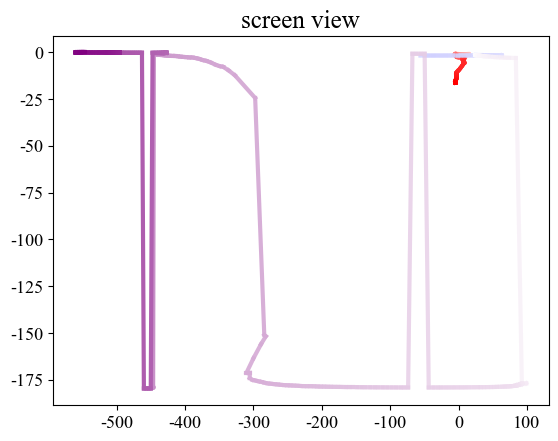

886


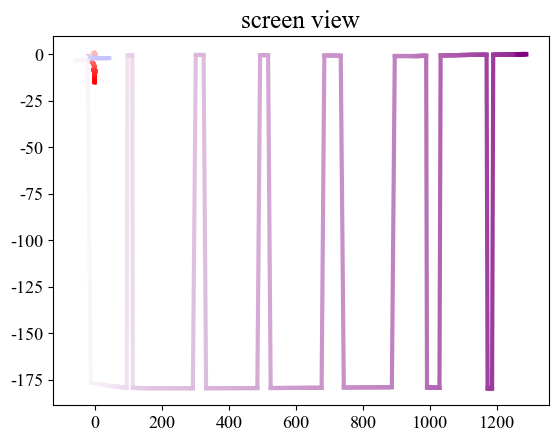

687


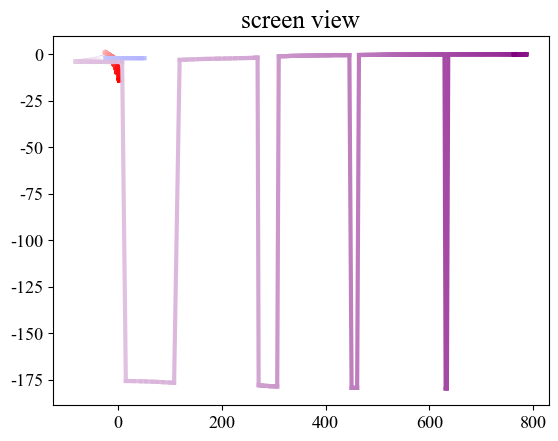

409


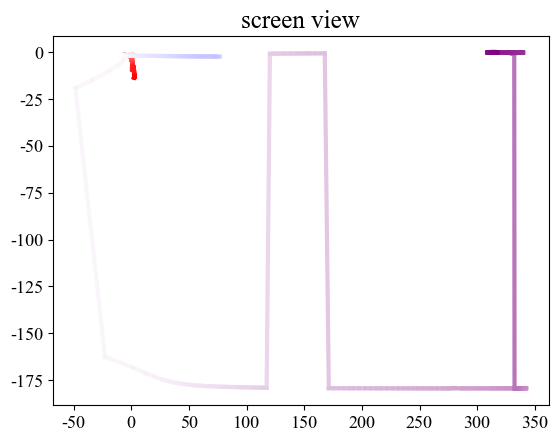

266


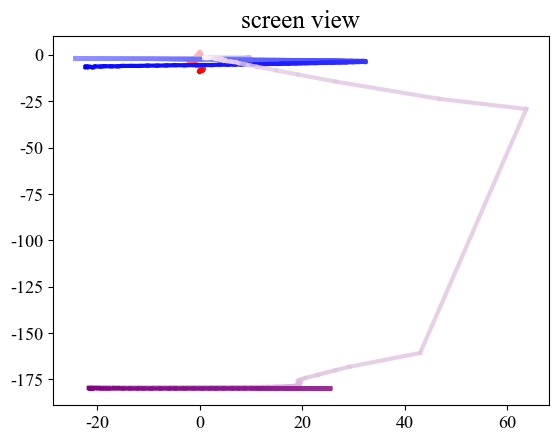

In [25]:
# screen view example trial

cmap_eye = mcolors.LinearSegmentedColormap.from_list('eye_cmap', ['white', eye_color])
cmap_state = mcolors.LinearSegmentedColormap.from_list('state_cmap', ['white', state_color])
cmap_belief = mcolors.LinearSegmentedColormap.from_list('belief_cmap', ['white', belief_color])

# trialidx=np.random.choice(sessdf.trial.unique())
for trialidx in [956,886,687,409,266]:
    print(trialidx)
    eye_hori = sessdf[sessdf.trial == trialidx].eye_hori.to_list()[0]
    eye_vert = sessdf[sessdf.trial == trialidx].eye_vert.to_list()[0]
    ff_hori = sessdf[sessdf.trial == trialidx].ff_hori.to_list()[0]
    ff_vert = sessdf[sessdf.trial == trialidx].ff_vert.to_list()[0]
    belief_ff_hori = sessdf[sessdf.trial == trialidx].belief_ff_hori.to_list()[0]
    belief_ff_vert = sessdf[sessdf.trial == trialidx].belief_ff_vert.to_list()[0]

    # Create the plot
    fig, ax = plt.subplots()
    # Plot the gradient lines with custom colormaps
    plot_gradient_line(ax, eye_hori, eye_vert, cmap_eye)
    plot_gradient_line(ax, ff_hori, ff_vert, cmap_state)
    plot_gradient_line(ax, belief_ff_hori, belief_ff_vert, cmap_belief)
    # plt.title(f'trial: {trialidx}')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    # ax.xaxis.set_ticks([])
    # ax.yaxis.set_ticks([])
    ax.set_title('screen view')
    plt.show()


956


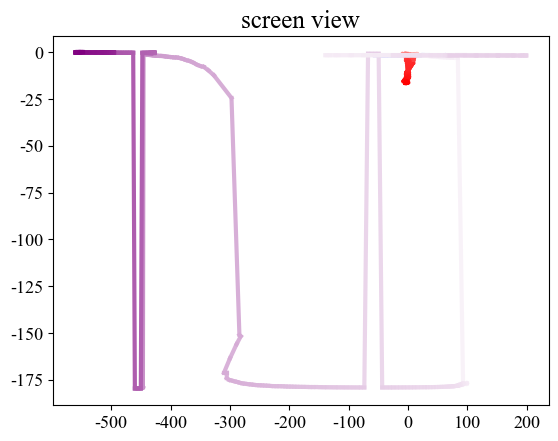

886


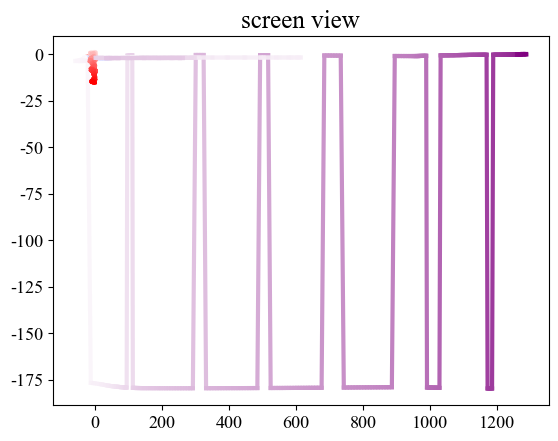

687


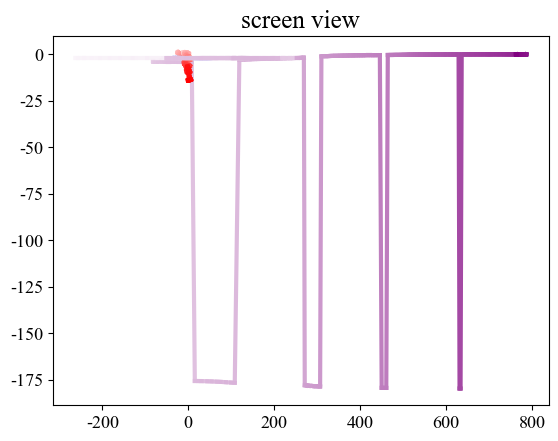

409


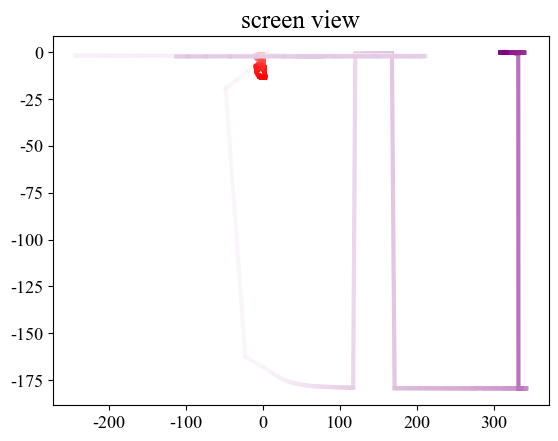

266


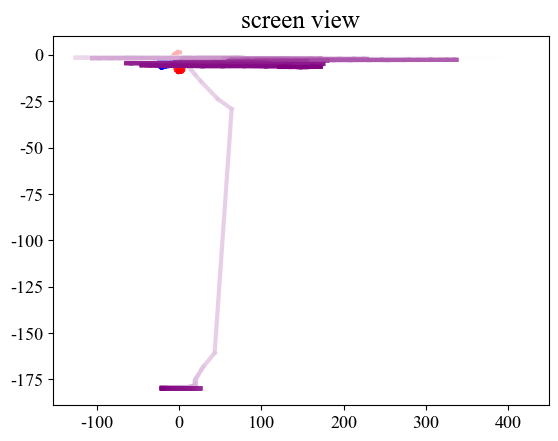

In [26]:
# screen view example trial (with neural belief and neural eye trajectory)

cmap_eye = mcolors.LinearSegmentedColormap.from_list('eye_cmap', ['white', eye_color])
cmap_state = mcolors.LinearSegmentedColormap.from_list('state_cmap', ['white', state_color])
cmap_belief = mcolors.LinearSegmentedColormap.from_list('belief_cmap', ['white', belief_color])

cmap_neuralbelief = mcolors.LinearSegmentedColormap.from_list('belief_cmap', ['white', belief_color])
cmap_neuraleye = mcolors.LinearSegmentedColormap.from_list('belief_cmap', ['white', eye_color])


thisr=np.vstack(timedf.PPC.to_list())
thise=timedf.eye.to_numpy().reshape(-1,1)
thisb=timedf.belief.to_numpy().reshape(-1,1)
neural2eye= LinearRegression()
neural2eye.fit(thisr, thise)
neural2belief= LinearRegression()
neural2belief.fit(thisr, thisb)



# trialidx=np.random.choice(sessdf.trial.unique())
for trialidx in [956,886,687,409,266]:
    print(trialidx)
    eye_hori = sessdf[sessdf.trial == trialidx].eye_hori.to_list()[0]
    eye_vert = sessdf[sessdf.trial == trialidx].eye_vert.to_list()[0]
    ff_hori = sessdf[sessdf.trial == trialidx].ff_hori.to_list()[0]
    ff_vert = sessdf[sessdf.trial == trialidx].ff_vert.to_list()[0]
    belief_ff_hori = sessdf[sessdf.trial == trialidx].belief_ff_hori.to_list()[0]
    belief_ff_vert = sessdf[sessdf.trial == trialidx].belief_ff_vert.to_list()[0]

    thisr=sessdf[sessdf.trial == trialidx].PPC.to_numpy()[0]

    neuralbelief=neural2belief.predict(thisr).reshape(-1)
    neuraleye=neural2eye.predict(thisr).reshape(-1)
    

    # Create the plot
    fig, ax = plt.subplots()
    # Plot the gradient lines with custom colormaps
    plot_gradient_line(ax, eye_hori, eye_vert, cmap_eye)
    plot_gradient_line(ax, ff_hori, ff_vert, cmap_state)
    plot_gradient_line(ax, belief_ff_hori, belief_ff_vert, cmap_belief)
    plot_gradient_line(ax, neuraleye, eye_vert, cmap_neuraleye)
    plot_gradient_line(ax, neuralbelief, ff_vert, cmap_neuralbelief)
    # plt.title(f'trial: {trialidx}')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    # ax.xaxis.set_ticks([])
    # ax.yaxis.set_ticks([])
    ax.set_title('screen view')
    plt.show()


Text(0.5, 0.98, 'not full on')

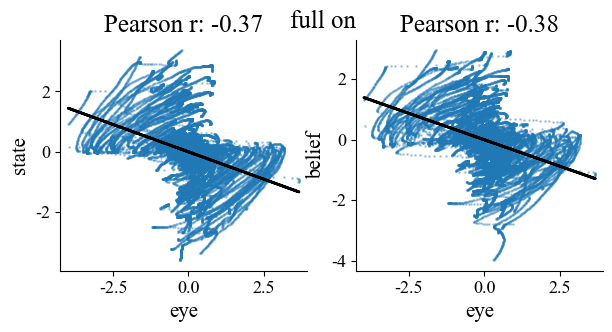

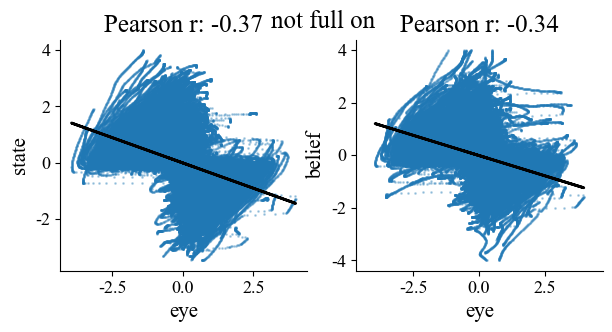

In [27]:
# correlation scatter
sessdf=df[df.fullon==1]

# state=np.concatenate(sessdf.heading.to_numpy())
# belief=np.concatenate(sessdf.belief_heading.to_numpy())
state=np.concatenate(sessdf.ff_hori.to_numpy())
belief=np.concatenate(sessdf.belief_ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())

mask=state!=0
state,belief,eye=state[mask],belief[mask],eye[mask]
related_taskvar = process([state, belief, eye])
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    axs[i].scatter(related_taskvar[:,2], related_taskvar[:,i], s=1, alpha=0.3)
    # axs[i].plot([-3,3],[-3,3],color='black', linewidth=1)

    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])

    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,j])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('full on')

sessdf=df[df.fullon==0]
# state=np.concatenate(sessdf.heading.to_numpy())
# belief=np.concatenate(sessdf.belief_heading.to_numpy())
state=np.concatenate(sessdf.ff_hori.to_numpy())
belief=np.concatenate(sessdf.belief_ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())

mask=state!=0
state,belief,eye=state[mask],belief[mask],eye[mask]
related_taskvar = process([state, belief, eye])
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    axs[i].scatter(related_taskvar[:,2], related_taskvar[:,i], s=1, alpha=0.3)
    # axs[i].plot([-3,3],[-3,3],color='black', linewidth=1)

    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])

    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,j])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on')

Text(0.5, 0.98, 'not full on')

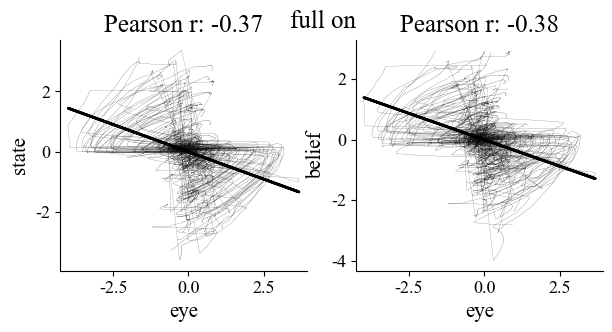

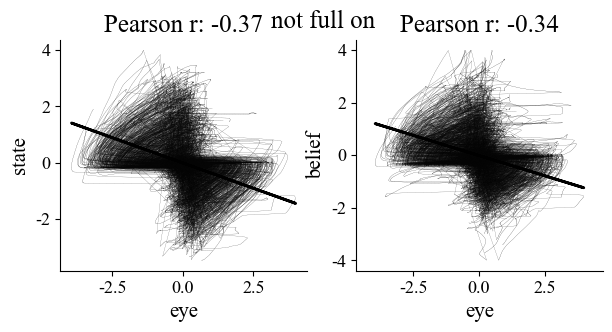

In [28]:
sessdf=df[df.fullon==1]
state=np.concatenate(sessdf.ff_hori.to_numpy())
belief=np.concatenate(sessdf.belief_ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timer=np.concatenate(sessdf.time_ratio.to_numpy())
mask=state!=0
state,belief,eye=state[mask],belief[mask],eye[mask]
timer=timer[mask]
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):

    for j in range(len(related_taskvar)-1):
        if timer[j]!=1:
            axs[i].plot([related_taskvar[j,2],related_taskvar[j+1,2]], [related_taskvar[j,i],related_taskvar[j+1,i]], linewidth=0.1, color='black')

    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('full on')

sessdf=df[df.fullon==0]
state=np.concatenate(sessdf.ff_hori.to_numpy())
belief=np.concatenate(sessdf.belief_ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timer=np.concatenate(sessdf.time_ratio.to_numpy())
mask=state!=0
state,belief,eye=state[mask],belief[mask],eye[mask]
timer=timer[mask]
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):

    for j in range(len(related_taskvar)-1):
        if timer[j]!=1:
            axs[i].plot([related_taskvar[j,2],related_taskvar[j+1,2]], [related_taskvar[j,i],related_taskvar[j+1,i]], linewidth=0.1, color='black')

    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on')

KeyboardInterrupt: 

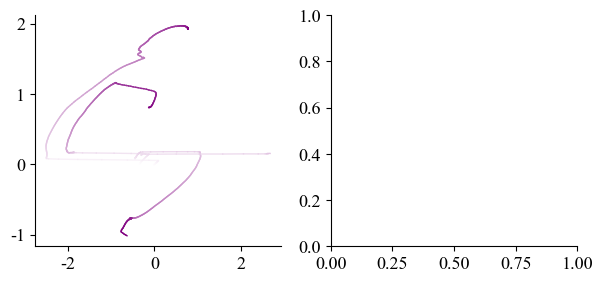

In [29]:
# full on,
sessdf=df[(df.fullon==1)]
state=np.concatenate(sessdf.ff_hori.to_numpy())
belief=np.concatenate(sessdf.belief_ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timer=np.concatenate(sessdf.time_ratio.to_numpy())
mask=state!=0
state,belief,eye=state[mask],belief[mask],eye[mask]
timer=timer[mask]
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]!=0:
            e+=1
        # print(s,e)
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('full on, all data')

Text(0.5, 0.98, 'full on')

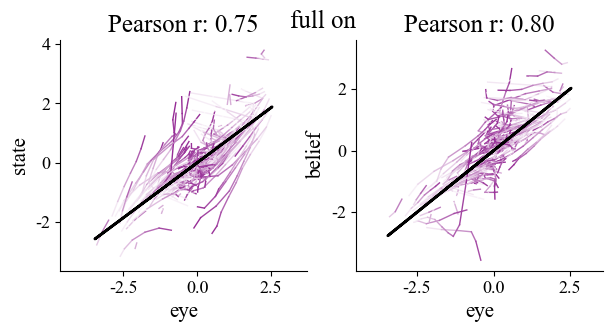

In [51]:
# full on, during trial
thisdf=timedf[(timedf.fullon==1)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('full on')

Text(0.5, 0.98, 'not full on')

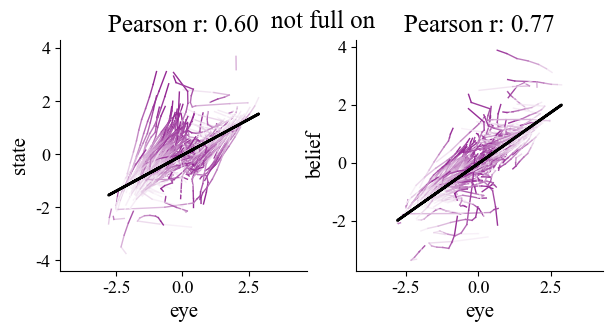

In [52]:
# not full on, during trial, error trials.
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))&(timedf.error>65)]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on')

Text(0.5, 0.98, 'not full on')

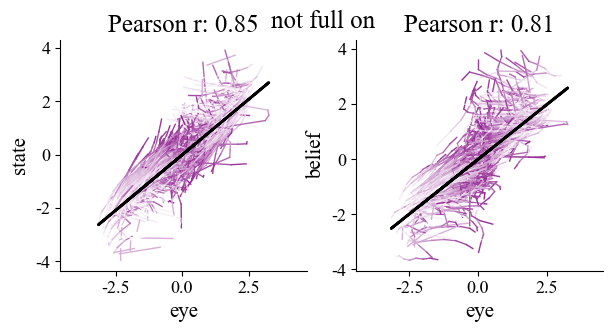

In [53]:
# not full on, during trial, success trials.
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))&(timedf.error<65)]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,3))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on')

Text(0, 0.5, 'prob')

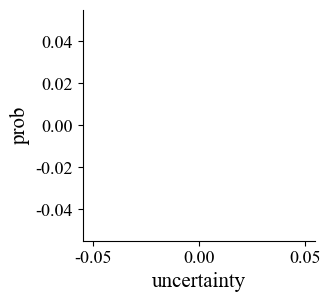

In [54]:
# when eye state differ: 
fig, ax = plt.subplots(1,1, figsize=(3,3))


thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()
uncertainty=np.stack(thisdf.uncertainty.to_numpy())[:,0,0]**0.5
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
uncertainty=uncertainty[mask]
ax.hist(uncertainty,density=True, bins=np.linspace(0,0.2,22), alpha=0.3)


thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.2))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()
uncertainty=np.stack(thisdf.uncertainty.to_numpy())[:,0,0]**0.5
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
uncertainty=uncertainty[mask]
ax.hist(uncertainty, alpha=0.3, density=True, bins=np.linspace(0,0.2,22))


thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()
uncertainty=np.stack(thisdf.uncertainty.to_numpy())[:,0,0]**0.5
related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
uncertainty=uncertainty[mask]


ax.hist(uncertainty, alpha=0.3, density=True, bins=np.linspace(0,0.2,22))

ax.set_xlabel(f'uncertainty')
ax.set_ylabel(f'prob')

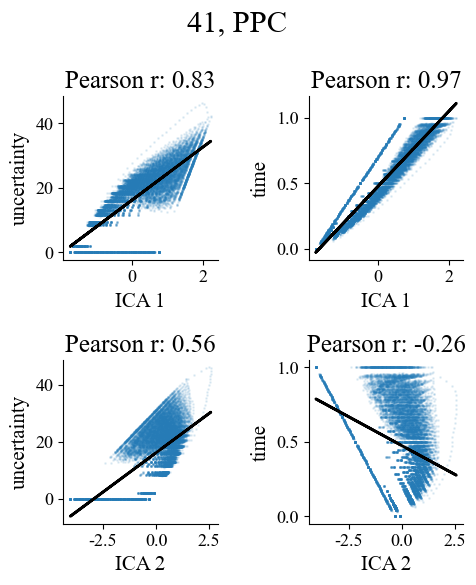

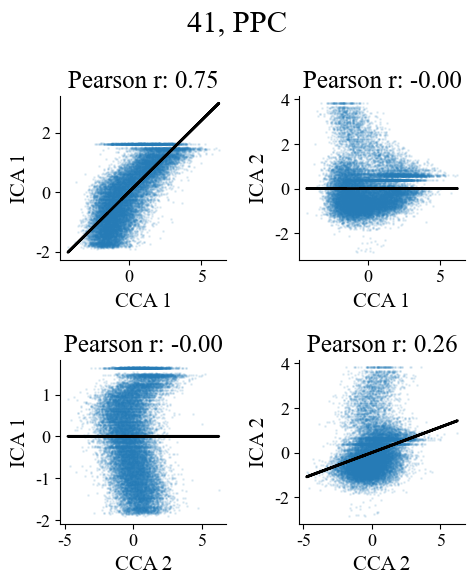

In [55]:
'''# use ica to seperate the time and uncerainty
'''
thisx,thisy,thisc=np.stack(timedf.PPC.to_numpy()),np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5,timedf.timeratio.to_numpy()
# thisy,thisc=zip(*process_list([thisy,thisc]))
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
# thisc,_=process_one(thisc)
thisxname, thisyname, thiscname='neural pred uncertainty', 'uncertainty','time ratio'

related_taskvar=np.stack([thisy, thisc]).T
ica = FastICA(n_components=2)
icaX=related_taskvar
icaS = ica.fit_transform(icaX) 


varname=['uncertainty', 'time']
fig, axs = plt.subplots(2,2, figsize=(5,6))
for i in range(2):
    for j in range(2):
        ax=axs[i,j]
        ax.scatter(icaS[:,i],related_taskvar[:,j], s=1, alpha=0.1)
        # best fit line
        slope, intercept = np.polyfit(icaS[:,i],related_taskvar[:,j], 1)
        best_fit_line = slope * icaS[:,i] + intercept
        ax.plot(icaS[:,i], best_fit_line, color='black')
        # quickallspine(ax)
        # ax.axis('equal')
        r,_=pearsonr(icaS[:,i],related_taskvar[:,j])
        # ax.set_title(f'x: cca {i+1} \ny: {varname[j]}\nPeason r: {r:.2f}')
        ax.set_title(f'Pearson r: {r:.2f}')
        ax.set_xlabel(f'ICA {i+1}')
        ax.set_ylabel(f'{varname[j]}')
plt.suptitle(f'{session}, PPC', fontsize=22)
plt.tight_layout()
plt.show()


thisx,thisy,thisc=np.stack(timedf.PPC.to_numpy()),np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5,timedf.timeratio.to_numpy()
# thisy,thisc=zip(*process_list([thisy,thisc]))
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
# thisc,_=process_one(thisc)
thisxname, thisyname, thiscname='neural pred uncertainty', 'uncertainty','time ratio'

related_taskvar=np.stack([thisy, thisc]).T
cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(thisx,icaS )


varname=['ICA 1', 'ICA 2']
fig, axs = plt.subplots(2,2, figsize=(5,6))
for i in range(2):
    for j in range(2):
        ax=axs[i,j]
        ax.scatter(cca_neural[:,i],cca_be[:,j], s=1, alpha=0.1)
        # best fit line
        slope, intercept = np.polyfit(cca_neural[:,i],cca_be[:,j], 1)
        best_fit_line = slope * cca_neural[:,i] + intercept
        ax.plot(cca_neural[:,i], best_fit_line, color='black')
        # quickallspine(ax)
        # ax.axis('equal')
        r,_=pearsonr(cca_neural[:,i],cca_be[:,j])
        # ax.set_title(f'x: cca {i+1} \ny: {varname[j]}\nPeason r: {r:.2f}')
        ax.set_title(f'Pearson r: {r:.2f}')
        ax.set_xlabel(f'CCA {i+1}')
        ax.set_ylabel(f'{varname[j]}')
plt.suptitle(f'{session}, PPC', fontsize=22)
plt.tight_layout()
plt.show()

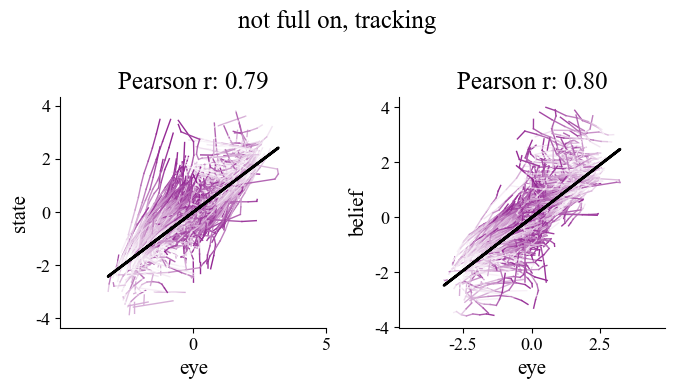

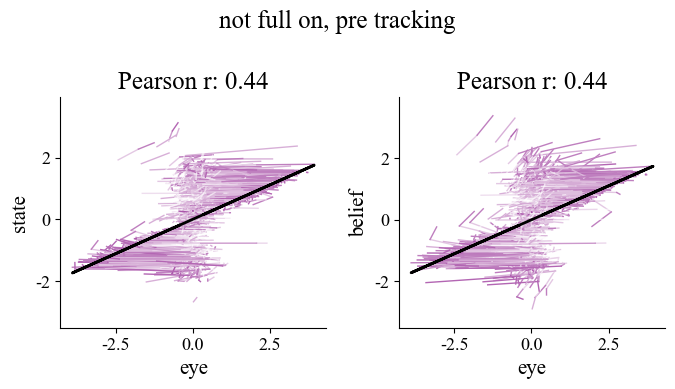

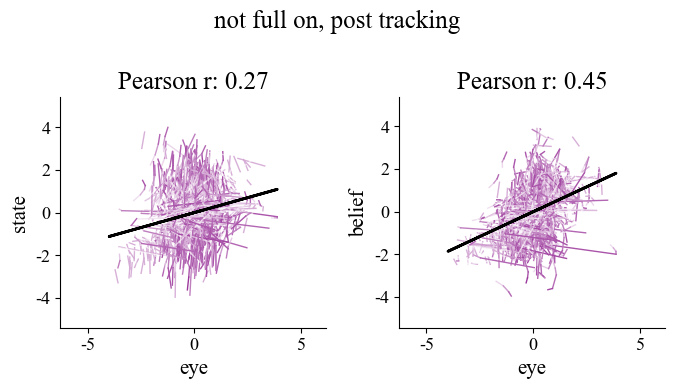

In [56]:
# tracking vs non tracking

# tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,4))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on, tracking')
plt.tight_layout()

# pre tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.2))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,4))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on, pre tracking')
plt.tight_layout()

# post tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]
state=thisdf.state.to_numpy()
belief=thisdf.belief.to_numpy()
eye=thisdf.eye.to_numpy()
timer=thisdf.timeratio.to_numpy()

related_taskvar, mask = process([state, belief, eye], returnmask=True)
timer=timer[mask]
names=['state', 'belief']
fig, axs = plt.subplots(1,2, figsize=(7,4))
for i in range(2):
    s=0
    while s<len(related_taskvar):
        e=s+1
        while e<len(related_taskvar) and timer[e]>timer[e-1]:
            e+=1
        e-1
        # print(s,e, timer[s], timer[e])
        plot_gradient_line(axs[i], related_taskvar[s:e,2], related_taskvar[s:e,i], cmap=cmap_belief, linewidth=1)
        s=e
    
    plot_best_fit(related_taskvar[:,2], related_taskvar[:,i],axs[i])
    axs[i].set_xlabel(f'eye')
    axs[i].set_ylabel(f'{names[i]}')
    axs[i].axis('equal')
    r,_=pearsonr(related_taskvar[:,i], related_taskvar[:,2])
    axs[i].set_title(f'Pearson r: {r:.2f}')
    k+=1
plt.suptitle('not full on, post tracking')
plt.tight_layout()

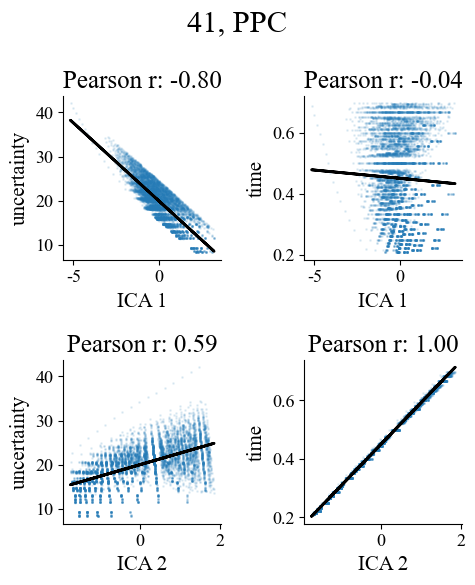

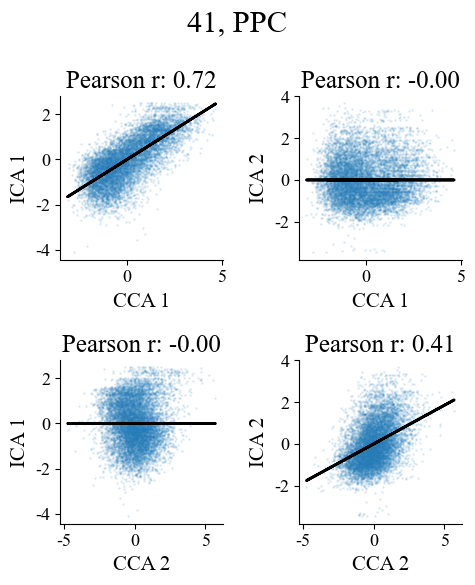

In [57]:
'''ica, 3 segment trial
'''

# pre tracking 
# thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.2))]

# tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]

# post tracking 
# thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]

thisx,thisy,thisc=np.stack(thisdf.PPC.to_numpy()),np.stack(thisdf.uncertainty.to_numpy())[:,0,0]**0.5,thisdf.timeratio.to_numpy()
# thisy,thisc=zip(*process_list([thisy,thisc]))
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
# thisc,_=process_one(thisc)
thisxname, thisyname, thiscname='neural pred uncertainty', 'uncertainty','time ratio'

related_taskvar=np.stack([thisy, thisc]).T
ica = FastICA(n_components=2)
icaX=related_taskvar
icaS = ica.fit_transform(icaX) 


varname=['uncertainty', 'time']
fig, axs = plt.subplots(2,2, figsize=(5,6))
for i in range(2):
    for j in range(2):
        ax=axs[i,j]
        ax.scatter(icaS[:,i],related_taskvar[:,j], s=1, alpha=0.1)
        # best fit line
        slope, intercept = np.polyfit(icaS[:,i],related_taskvar[:,j], 1)
        best_fit_line = slope * icaS[:,i] + intercept
        ax.plot(icaS[:,i], best_fit_line, color='black')
        # quickallspine(ax)
        # ax.axis('equal')
        r,_=pearsonr(icaS[:,i],related_taskvar[:,j])
        # ax.set_title(f'x: cca {i+1} \ny: {varname[j]}\nPeason r: {r:.2f}')
        ax.set_title(f'Pearson r: {r:.2f}')
        ax.set_xlabel(f'ICA {i+1}')
        ax.set_ylabel(f'{varname[j]}')
plt.suptitle(f'{session}, PPC', fontsize=22)
plt.tight_layout()
plt.show()


thisx,thisy,thisc=np.stack(thisdf.PPC.to_numpy()),np.stack(thisdf.uncertainty.to_numpy())[:,0,0]**0.5,thisdf.timeratio.to_numpy()
# thisy,thisc=zip(*process_list([thisy,thisc]))
thisx,thisy,thisc=np.array(thisx),np.array(thisy),np.array(thisc)
# thisc,_=process_one(thisc)
thisxname, thisyname, thiscname='neural pred uncertainty', 'uncertainty','time ratio'

related_taskvar=np.stack([thisy, thisc]).T
cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(thisx,icaS )


varname=['ICA 1', 'ICA 2']
fig, axs = plt.subplots(2,2, figsize=(5,6))
for i in range(2):
    for j in range(2):
        ax=axs[i,j]
        ax.scatter(cca_neural[:,i],cca_be[:,j], s=1, alpha=0.1)
        # best fit line
        slope, intercept = np.polyfit(cca_neural[:,i],cca_be[:,j], 1)
        best_fit_line = slope * cca_neural[:,i] + intercept
        ax.plot(cca_neural[:,i], best_fit_line, color='black')
        # quickallspine(ax)
        # ax.axis('equal')
        r,_=pearsonr(cca_neural[:,i],cca_be[:,j])
        # ax.set_title(f'x: cca {i+1} \ny: {varname[j]}\nPeason r: {r:.2f}')
        ax.set_title(f'Pearson r: {r:.2f}')
        ax.set_xlabel(f'CCA {i+1}')
        ax.set_ylabel(f'{varname[j]}')
plt.suptitle(f'{session}, PPC', fontsize=22)
plt.tight_layout()
plt.show()

# new, sessdf, 1 trial 3 part


In [418]:
sessdf=df[(df.session==session)]
sessdf.columns

Index(['trial', 'session', 'fullon', 'density', 'eye_hori', 'eye_vert',
       'ff_hori', 'ff_vert', 'fx', 'fy', 'mx', 'my', 'mv', 'mw', 'PPC', 'PFC',
       'MST', 'error', 'error_sign', 'target_angle', 'target_distance',
       'state', 'action', 'task', 'likelihood', 'belief', 'rawcov', 'bmx',
       'bmy', 'heading', 'belief_heading', 'timer', 'countdown',
       'belief_ff_hori', 'belief_ff_vert', 'angle_from_start',
       'belief_angle_from_start', 'relcov', 'state_error', 'belief_error',
       'time_ratio'],
      dtype='object')

In [419]:
belief_arrays=sessdf.belief_ff_hori.tolist()
eye_arrays=sessdf.eye_hori.tolist()

def normalize_list_of_arrays(array_list):
    # Concatenate all arrays to compute global statistics
    all_values = np.concatenate(array_list)
    
    # Compute global mean and standard deviation
    global_mean = np.mean(all_values)
    global_std = np.std(all_values)
    
    # Normalize each array using the global statistics
    normalized_arrays = [(arr - global_mean) / global_std for arr in array_list]
    
    return normalized_arrays


belief_arrays=normalize_list_of_arrays(belief_arrays)
eye_arrays=normalize_list_of_arrays(eye_arrays)
neural_data=list(np.vstack(sessdf.PPC.to_numpy()))

In [420]:

len(belief_arrays), len(np.concatenate(belief_arrays)), len(np.concatenate(sessdf.belief_ff_hori.to_numpy()))

(1538, 24705, 24705)

In [421]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from itertools import groupby
def adaptive_window_size(trial_length):
    return min(max(0.1, 3/trial_length), 0.2)

def find_correlation_phases(belief, eye, window_size=0.1, threshold=0.5):
    """
    Find periods of correlation between belief and eye signals.
    
    Parameters:
    -----------
    belief : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye : list of numpy.ndarray
        List where each item is the eye signal for one trial
    window_size : float
        Size of the rolling window as a fraction of trial length
    threshold : float
        Correlation coefficient threshold for determining correlation
        
    Returns:
    --------
    points : numpy.ndarray
        Array of shape (n_trials, 2) containing [start_corr_idx, end_corr_idx] for each trial
    """
    n_trials = len(belief)
    results = np.zeros((n_trials, 2), dtype=int)
    
    for trial in range(n_trials):
        b = belief[trial]
        e = eye[trial]
        
        # Ensure signals are of the same length
        if len(b) != len(e):
            raise ValueError(f"Signal lengths don't match for trial {trial}: {len(b)} vs {len(e)}")
        
        time_points = len(b)
        window_size = adaptive_window_size(time_points)

        window_points = min(max(int(window_size * time_points), 5), time_points // 2)
        
        # # If trial is too short, use default values and continue
        # if window_points < 5 or time_points < 10:
        #     print(f"Warning: Trial {trial} is too short ({time_points} points). Using default values.")
        #     results[trial, 0] = 0
        #     results[trial, 1] = time_points - 1
        
        #     continue
        
        # Calculate rolling correlation
        n_windows = time_points - window_points + 1
        
        # Double-check to ensure n_windows is positive
        if n_windows <= 0:
            print(f"Warning: Trial {trial} is too short for the window size. Using default values.")
            results[trial, 0] = 0
            results[trial, 1] = time_points - 1
            continue
            
        correlations = np.zeros(n_windows)
        
        for i in range(n_windows):
            b_window = b[i:i+window_points]
            e_window = e[i:i+window_points]
            try:
                r, p = stats.pearsonr(b_window, e_window)
                correlations[i] = abs(r)  # Use absolute correlation
            except:
                # Handle potential exceptions during correlation calculation
                correlations[i] = 0
        
        # Find where correlation rises above threshold
        corr_periods = correlations > threshold
        
        if not any(corr_periods):
            # No correlation found above threshold, use default values
            start_idx = int(0.2 * time_points)  # Default: 20% into trial
            end_idx = int(0.8 * time_points)    # Default: 80% into trial
        else:
            # Find the longest continuous period of correlation
            groups = [(k, sum(1 for _ in g)) for k, g in groupby(corr_periods)]
            
            # Filter for correlation periods (where k is True)
            corr_groups = [(i, length) for i, (k, length) in enumerate(groups) if k]
            
            if corr_groups:
                # Find the longest correlation period
                longest_idx = max(corr_groups, key=lambda x: x[1])[0]
                
                # Calculate the start index in the original array
                start_idx = sum(groups[i][1] for i in range(longest_idx))
                
                # Calculate the end index
                end_idx = start_idx + groups[longest_idx][1] - 1
                
                # Adjust for the window size
                start_idx = start_idx
                end_idx = min(end_idx + window_points, time_points - 1)
            else:
                # Fallback to defaults if no correlation groups found
                start_idx = int(0.2 * time_points)
                end_idx = int(0.8 * time_points)
        
        results[trial, 0] = start_idx
        results[trial, 1] = end_idx
        
    return results


def visualize_correlation_analysis(belief, eye, detected_points, trials_to_plot=None):
    """
    Visualize the belief and eye signals, their correlation, and detected phases.
    
    Parameters:
    -----------
    belief : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye : list of numpy.ndarray
        List where each item is the eye signal for one trial
    detected_points : numpy.ndarray
        Array of shape (n_trials, 2) with detected points
    trials_to_plot : list or None
        List of trial indices to plot. If None, plots first few trials.
    """
    n_trials = len(belief)
    
    if trials_to_plot is None:
        trials_to_plot = range(min(n_trials, 3))  # Plot at most 3 trials by default
    
    for idx in trials_to_plot:
        if idx >= n_trials:
            print(f"Trial index {idx} out of range (max: {n_trials-1})")
            continue
            
        b = belief[idx]
        e = eye[idx]
        n_timepoints = len(b)
        
        # Skip if trial is too short
        if n_timepoints < 10:
            print(f"Trial {idx} is too short ({n_timepoints} points) for visualization. Skipping.")
            continue
        
        # Create time ratio for coloring
        time_ratio = np.linspace(0, 1, n_timepoints)
        
        fig = plt.figure(figsize=(18, 12))
        
        # Plot 1: Time series of both signals
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.plot(b, 'b-', label='Belief')
        ax1.plot(e, 'r-', label='Eye')
        
        # Highlight the detected correlation region
        start_idx = detected_points[idx, 0]
        end_idx = detected_points[idx, 1]
        
        rect = Rectangle((start_idx, ax1.get_ylim()[0]), end_idx - start_idx, 
                         ax1.get_ylim()[1] - ax1.get_ylim()[0], 
                         color='green', alpha=0.2)
        ax1.add_patch(rect)
        ax1.axvline(x=start_idx, color='g', linestyle='--', label='Start Correlation')
        ax1.axvline(x=end_idx, color='r', linestyle='--', label='End Correlation')
        
        ax1.set_title(f'Trial {idx+1}: Belief and Eye Signals')
        ax1.legend(loc='upper right')
        ax1.grid(True)
        ax1.set_xlabel('Time Points')
        ax1.set_ylabel('Normalized Value')
        
        # Plot 2: Scatter plot of belief vs eye, colored by time
        ax2 = fig.add_subplot(2, 2, 2)
        scatter = ax2.scatter(b, e, c=time_ratio, cmap='viridis', alpha=0.7)
        
        # Highlight points in correlation phase
        if start_idx < end_idx:  # Only if there's a valid correlation region
            ax2.scatter(b[start_idx:end_idx+1], e[start_idx:end_idx+1], 
                       c=time_ratio[start_idx:end_idx+1], cmap='viridis', 
                       marker='o', s=50, edgecolors='red', linewidths=1)
        
        ax2.set_title('Belief vs Eye (colored by time ratio)')
        ax2.set_xlabel('Belief')
        ax2.set_ylabel('Eye')
        ax2.grid(True)
        fig.colorbar(scatter, ax=ax2, label='Time Ratio in Trial')
        
        # Plot 3: Rolling correlation
        ax3 = fig.add_subplot(2, 2, 3)
        
        # Calculate window size for visualization
        window_points = min(max(int(0.1 * n_timepoints), 5), n_timepoints // 2)
        
        if window_points < 5:
            ax3.text(0.5, 0.5, "Trial too short for correlation analysis", 
                     horizontalalignment='center', verticalalignment='center',
                     transform=ax3.transAxes)
        else:
            n_windows = n_timepoints - window_points + 1
            correlations = np.zeros(n_windows)
            
            for i in range(n_windows):
                b_window = b[i:i+window_points]
                e_window = e[i:i+window_points]
                try:
                    r, p = stats.pearsonr(b_window, e_window)
                    correlations[i] = abs(r)
                except:
                    correlations[i] = 0
            
            ax3.plot(np.arange(window_points//2, n_windows + window_points//2), correlations, 'k-')
            ax3.axhline(y=0.5, color='gray', linestyle='--', label='Threshold (0.5)')
            ax3.axvline(x=start_idx, color='g', linestyle='--')
            ax3.axvline(x=end_idx, color='r', linestyle='--')
            
            ax3.set_title('Rolling Correlation')
            ax3.set_xlabel('Time Points')
            ax3.set_ylabel('|Correlation Coefficient|')
            ax3.grid(True)
            ax3.legend()
        
        # Plot 4: Subphase analysis
        ax4 = fig.add_subplot(2, 2, 4)
        
        # Divide the trial into three phases
        pre_corr = list(range(0, start_idx))
        corr = list(range(start_idx, min(end_idx+1, n_timepoints)))
        post_corr = list(range(min(end_idx+1, n_timepoints), n_timepoints))
        
        # Calculate phase-specific correlations
        pre_r, corr_r, post_r = 0, 0, 0
        
        if len(pre_corr) > 5:
            try:
                pre_r = stats.pearsonr(b[pre_corr], e[pre_corr])[0]
            except:
                pre_r = 0
            
        if len(corr) > 5:
            try:
                corr_r = stats.pearsonr(b[corr], e[corr])[0]
            except:
                corr_r = 0
            
        if len(post_corr) > 5:
            try:
                post_r = stats.pearsonr(b[post_corr], e[post_corr])[0]
            except:
                post_r = 0
        
        phases = ['Pre-correlation', 'Correlation', 'Post-correlation']
        r_values = [pre_r, corr_r, post_r]
        
        ax4.bar(phases, r_values, color=['blue', 'green', 'red'])
        ax4.set_title('Correlation by Phase')
        ax4.set_ylabel('Pearson Correlation')
        ax4.grid(True, axis='y')
        ax4.set_ylim(-1, 1)  # Ensure y-axis shows full correlation range
        
        # Add text with phase time ranges
        for i, (phase, r) in enumerate(zip(phases, r_values)):
            y_pos = max(min(r + 0.1, 0.9), -0.9)  # Position text based on bar height
            if i == 0:
                ax4.text(i, y_pos, f"Time: 0-{start_idx/n_timepoints:.2f}", ha='center')
            elif i == 1:
                ax4.text(i, y_pos, f"Time: {start_idx/n_timepoints:.2f}-{end_idx/n_timepoints:.2f}", ha='center')
            else:
                ax4.text(i, y_pos, f"Time: {end_idx/n_timepoints:.2f}-1.0", ha='center')
        
        plt.tight_layout()
        plt.show()

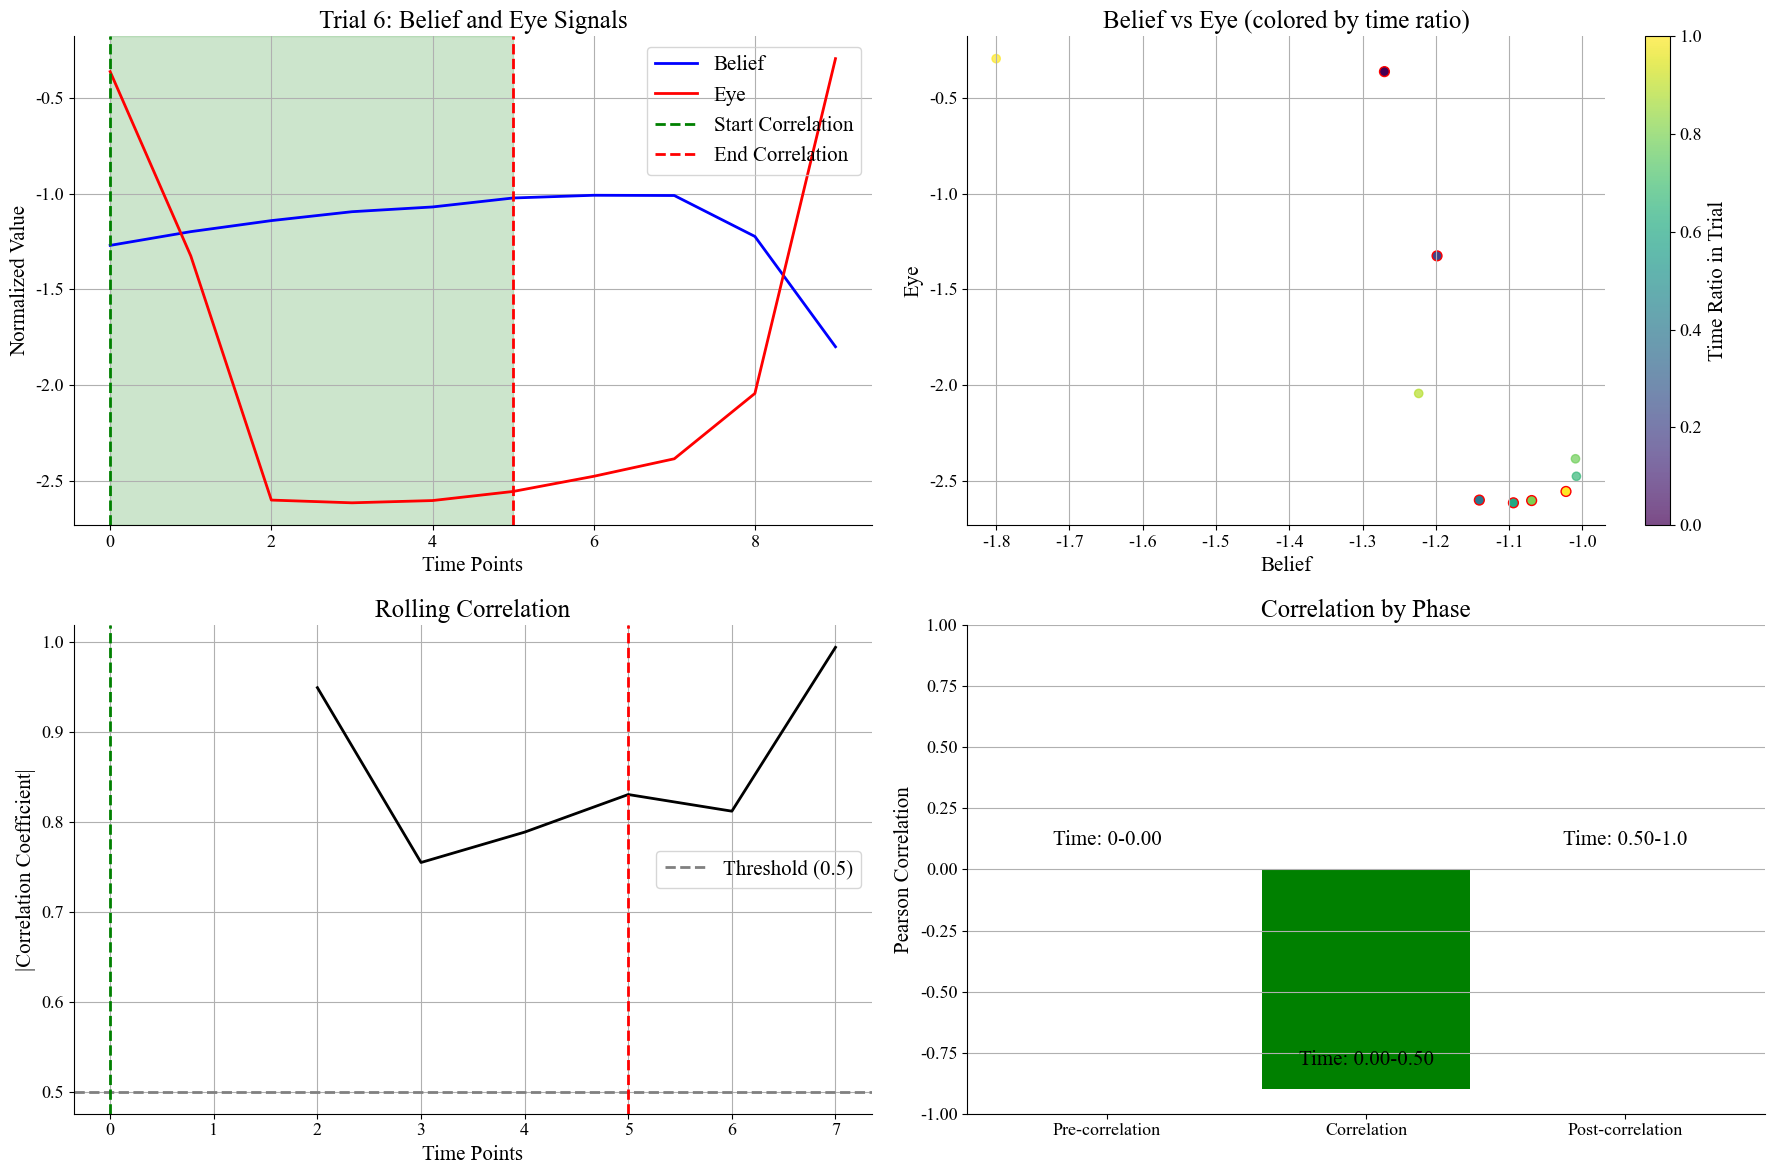

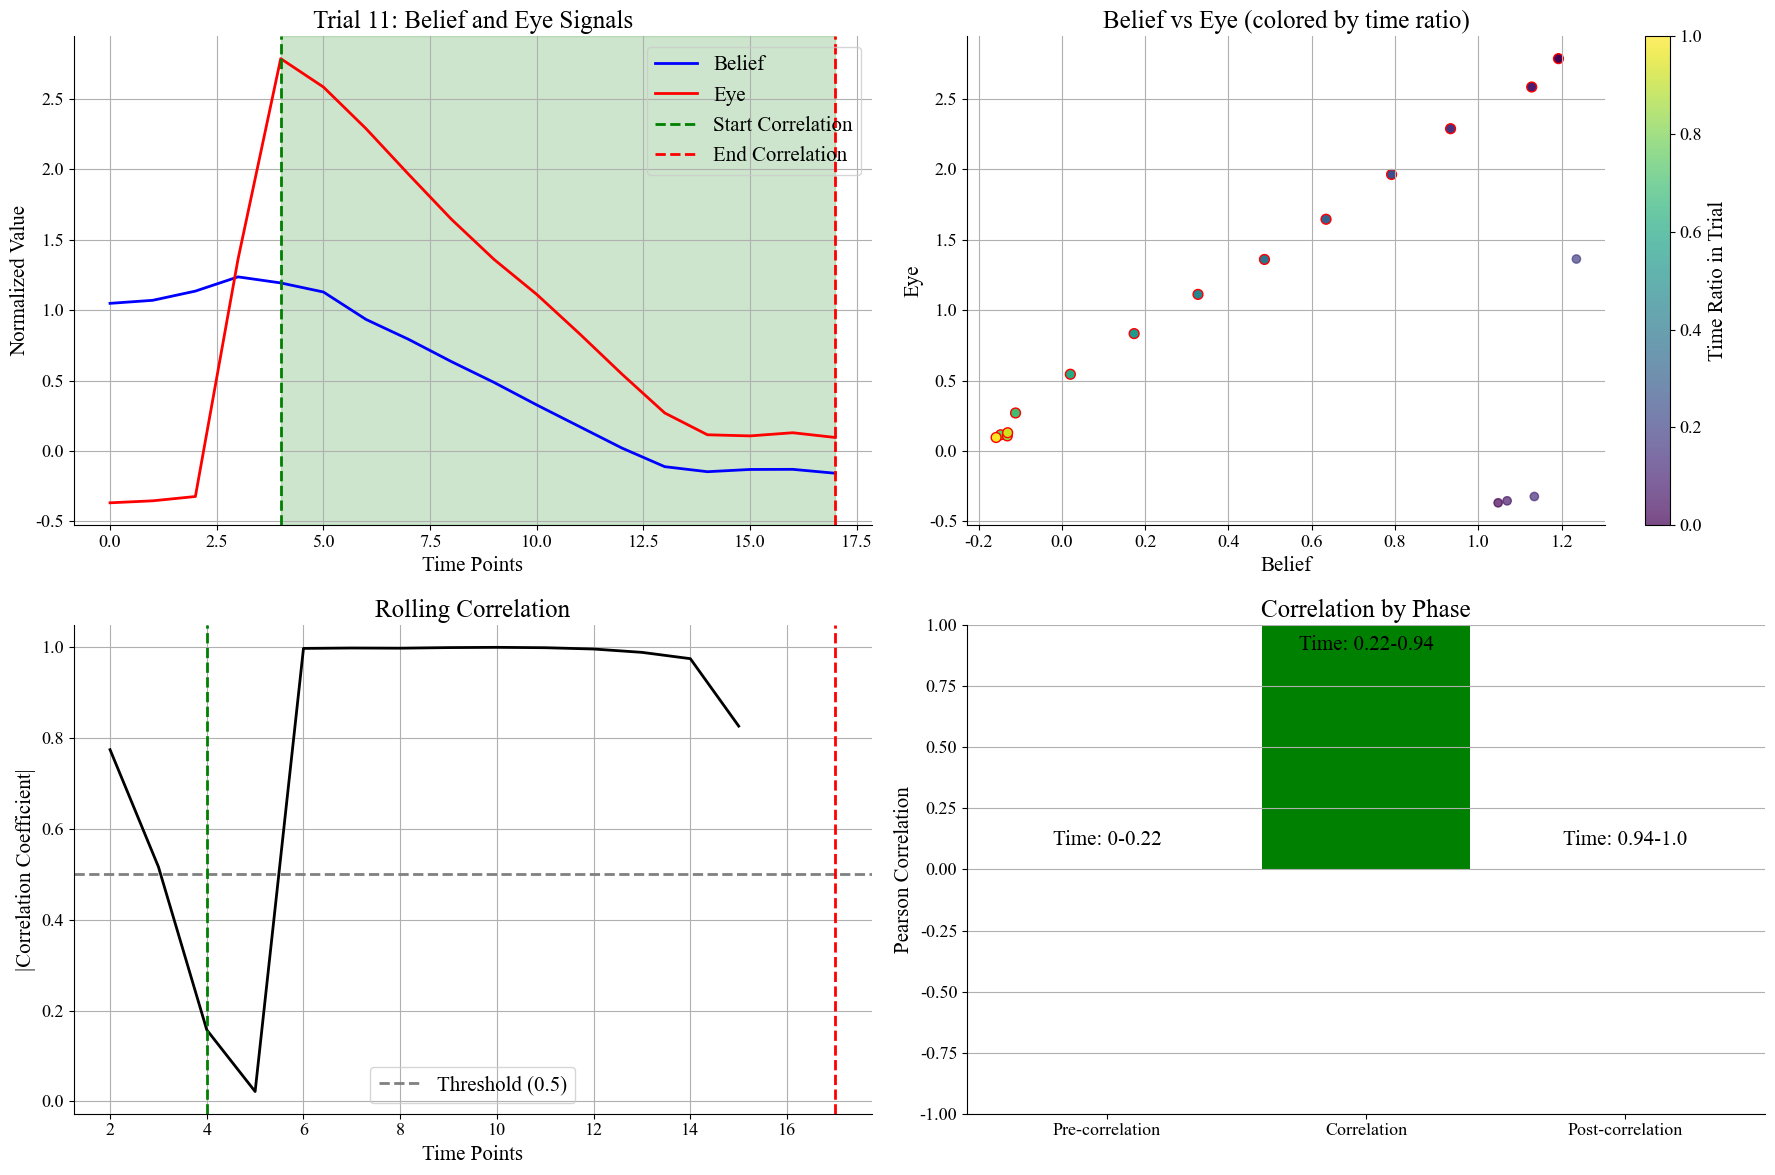

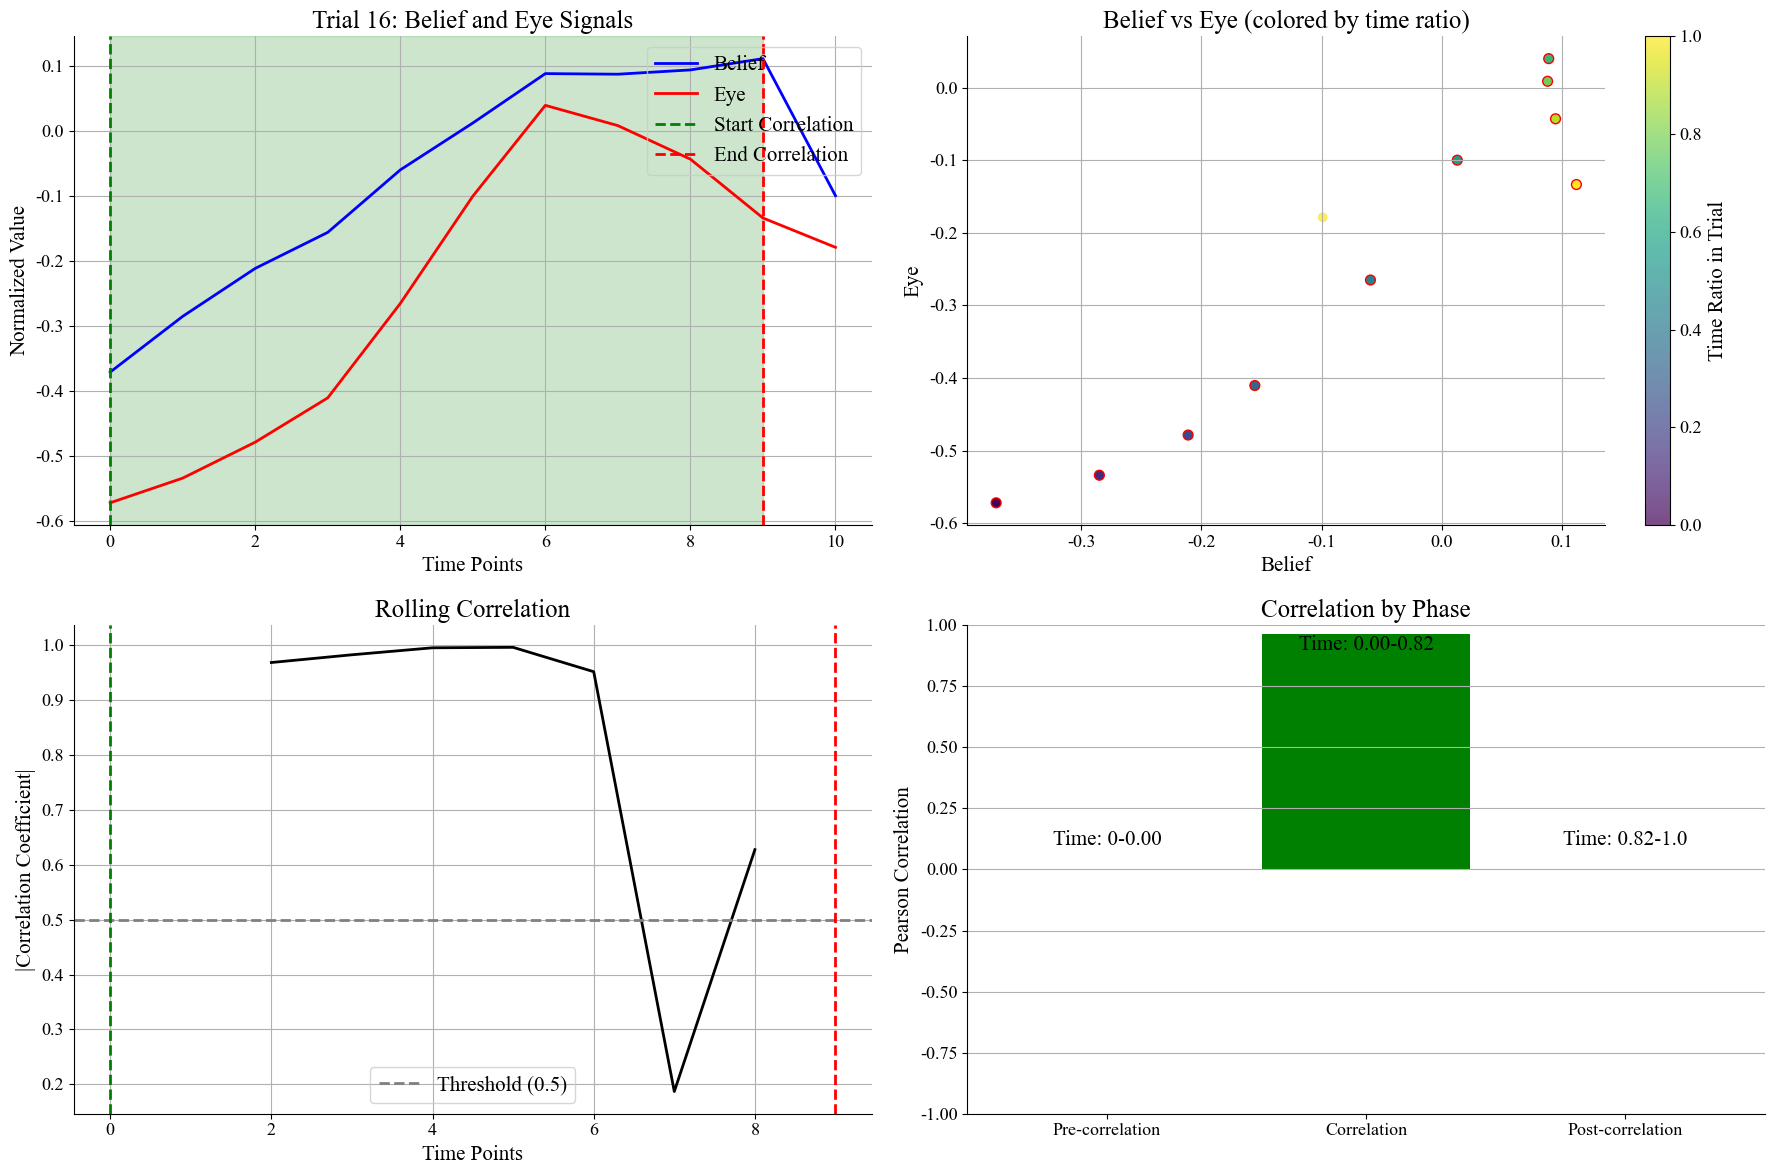

In [422]:
# First, detect the correlation phases in your data
detected_phases = find_correlation_phases(belief_arrays, eye_arrays, window_size=0.2, threshold=0.9)

# visualize_correlation_analysis(belief_arrays, eye_arrays, detected_phases)
visualize_correlation_analysis(belief_arrays, eye_arrays, detected_phases, trials_to_plot=[5, 10, 15])

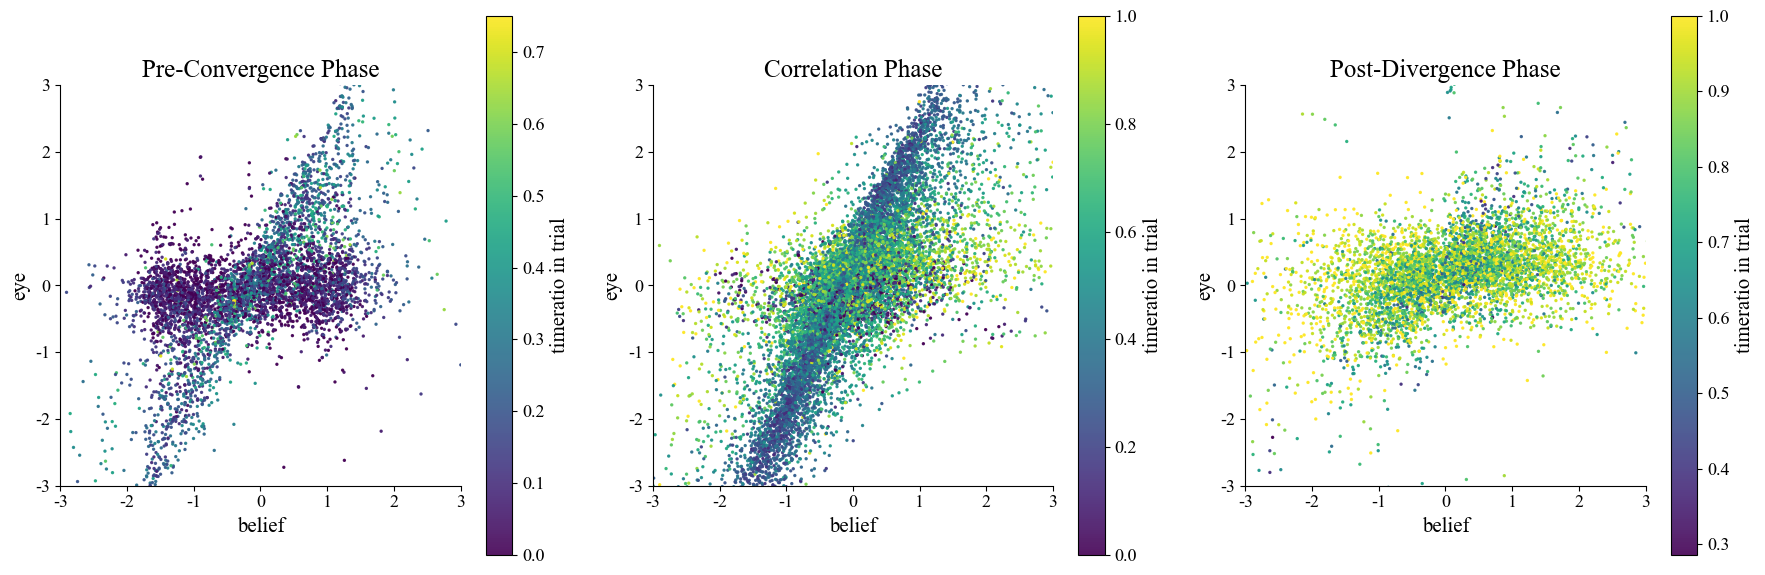

Points in pre-convergence phase: 5497
Points in correlation phase: 13482
Points in post-divergence phase: 5726


In [423]:
import numpy as np
import matplotlib.pyplot as plt

def plot_three_phases(belief_arrays, eye_arrays, detected_phases):
    """
    Create three separate scatter plots for pre-convergence, correlation, and post-divergence phases.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    detected_phases : numpy.ndarray
        Array of shape (n_trials, 2) with detected convergence/divergence points
    """
    # Create empty lists to collect all points from each phase
    pre_belief, pre_eye, pre_time = [], [], []
    corr_belief, corr_eye, corr_time = [], [], []
    post_belief, post_eye, post_time = [], [], []
    
    # Process each trial
    for trial_idx in range(len(belief_arrays)):
        b = belief_arrays[trial_idx]
        e = eye_arrays[trial_idx]
        start_idx = detected_phases[trial_idx, 0]
        end_idx = detected_phases[trial_idx, 1]
        
        # Create time ratio for this trial
        timer_values = np.linspace(0, 1, len(b))
        
        # Pre-convergence phase
        pre_belief.extend(b[:start_idx])
        pre_eye.extend(e[:start_idx])
        pre_time.extend(timer_values[:start_idx])
        
        # Correlation phase
        corr_belief.extend(b[start_idx:end_idx+1])
        corr_eye.extend(e[start_idx:end_idx+1])
        corr_time.extend(timer_values[start_idx:end_idx+1])
        
        # Post-divergence phase
        post_belief.extend(b[end_idx+1:])
        post_eye.extend(e[end_idx+1:])
        post_time.extend(timer_values[end_idx+1:])
    
    # Create the three scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Pre-convergence
    sc1 = axes[0].scatter(pre_belief, pre_eye, c=pre_time, cmap='viridis', s=2, alpha=0.9)
    axes[0].set_title('Pre-Convergence Phase')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    plt.colorbar(sc1, ax=axes[0], label='timeratio in trial')
    
    # Plot 2: Correlation period
    sc2 = axes[1].scatter(corr_belief, corr_eye, c=corr_time, cmap='viridis', s=2, alpha=0.9)
    axes[1].set_title('Correlation Phase')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    plt.colorbar(sc2, ax=axes[1], label='timeratio in trial')
    
    # Plot 3: Post-divergence
    sc3 = axes[2].scatter(post_belief, post_eye, c=post_time, cmap='viridis', s=2, alpha=0.9)
    axes[2].set_title('Post-Divergence Phase')
    axes[2].set_xlabel('belief')
    axes[2].set_ylabel('eye')
    axes[2].set_xlim(-3, 3)
    axes[2].set_ylim(-3, 3)
    axes[2].set_aspect('equal')
    plt.colorbar(sc3, ax=axes[2], label='timeratio in trial')
    
    plt.tight_layout()
    plt.show()
    
    # Return count statistics
    return {
        'pre_count': len(pre_belief),
        'correlation_count': len(corr_belief),
        'post_count': len(post_belief),
        'total_points': len(pre_belief) + len(corr_belief) + len(post_belief)
    }

# Usage:
point_stats = plot_three_phases(belief_arrays, eye_arrays, detected_phases)
print(f"Points in pre-convergence phase: {point_stats['pre_count']}")
print(f"Points in correlation phase: {point_stats['correlation_count']}")
print(f"Points in post-divergence phase: {point_stats['post_count']}")

In [424]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cross_decomposition import CCA

def plot_three_phases_cca(belief_arrays, eye_arrays, neural_data, detected_phases):
    """
    Create three separate scatter plots for pre-convergence, correlation, and post-divergence phases,
    colored by CCA dimensions.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    neural_data : numpy.ndarray
        Neural data corresponding to each time point
    detected_phases : numpy.ndarray
        Array of shape (n_trials, 2) with detected convergence/divergence points
    """
    # First, convert the list of arrays into flat arrays with trial information
    all_belief = []
    all_eye = []
    all_neural = []
    all_trial_idx = []
    all_time_idx = []
    
    for trial_idx in range(len(belief_arrays)):
        trial_len = len(belief_arrays[trial_idx])
        all_belief.extend(belief_arrays[trial_idx])
        all_eye.extend(eye_arrays[trial_idx])
        

        start_idx = sum(len(belief_arrays[i]) for i in range(trial_idx))
        end_idx = start_idx + trial_len
        if end_idx <= len(neural_data):
            all_neural.extend(neural_data[start_idx:end_idx])
    
        all_trial_idx.extend([trial_idx] * trial_len)
        all_time_idx.extend(list(range(trial_len)))
    
    # Convert to numpy arrays
    all_belief = np.array(all_belief)
    all_eye = np.array(all_eye)
    all_neural = np.array(all_neural)
    all_trial_idx = np.array(all_trial_idx)
    all_time_idx = np.array(all_time_idx)
    
    # Combine belief and eye into related_taskvar
    related_taskvar = np.column_stack((all_belief, all_eye))
    
    # Apply the same preprocessing as in your original code
    mask = (related_taskvar > -4) & (related_taskvar < 4)
    mask = mask[:,0] & mask[:,1]
    
    related_taskvar = related_taskvar[mask]
    all_neural = all_neural[mask]
    all_trial_idx = all_trial_idx[mask]
    all_time_idx = all_time_idx[mask]
    
    # Run CCA
    cca = CCA(n_components=2)
    cca_neural, cca_be = cca.fit_transform(all_neural, related_taskvar)
    
    # Generate RGB values from CCA components
    t1, t2 = cca_neural[:,0], cca_neural[:,1]
    
    c1 = np.array([1,0,0])  # Red for CCA1
    c2 = np.array([0,0,1])  # Blue for CCA2
    
    rgb_values = np.zeros((len(t1), 3))
    rgb_values[:,[0,2]] = 0.25
    rgb_values += (c1[None,:] * t1[:,None])
    rgb_values += (c2[None,:] * t2[:,None])
    
    rgb_values = rgb_values.clip(0, 1)
    hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
    
    # Create indexes for each phase based on detected_phases
    pre_idx = []
    corr_idx = []
    post_idx = []
    
    for i, (trial, time_idx) in enumerate(zip(all_trial_idx, all_time_idx)):
        if trial < len(detected_phases):
            start_idx, end_idx = detected_phases[trial]
            if time_idx < start_idx:
                pre_idx.append(i)
            elif start_idx <= time_idx <= end_idx:
                corr_idx.append(i)
            else:
                post_idx.append(i)
    
    # Create the three scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Pre-convergence
    axes[0].scatter(
        related_taskvar[pre_idx, 0], 
        related_taskvar[pre_idx, 1], 
        c=[hex_colors[i] for i in pre_idx], 
        s=2, alpha=0.9
    )
    axes[0].set_title('Pre-Convergence Phase')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    
    # Plot 2: Correlation period
    axes[1].scatter(
        related_taskvar[corr_idx, 0], 
        related_taskvar[corr_idx, 1], 
        c=[hex_colors[i] for i in corr_idx], 
        s=2, alpha=0.9
    )
    axes[1].set_title('Correlation Phase')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    
    # Plot 3: Post-divergence
    axes[2].scatter(
        related_taskvar[post_idx, 0], 
        related_taskvar[post_idx, 1], 
        c=[hex_colors[i] for i in post_idx], 
        s=2, alpha=0.9
    )
    axes[2].set_title('Post-Divergence Phase')
    axes[2].set_xlabel('belief')
    axes[2].set_ylabel('eye')
    axes[2].set_xlim(-3, 3)
    axes[2].set_ylim(-3, 3)
    axes[2].set_aspect('equal')
    
    # Add a legend/text to explain the coloring
    fig.text(0.5, 0.01, 'CCA 1: black --> red\nCCA 2: black --> blue', 
             ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Return statistics
    return {
        'pre_count': len(pre_idx),
        'correlation_count': len(corr_idx),
        'post_count': len(post_idx),
        'total_points': len(related_taskvar)
    }

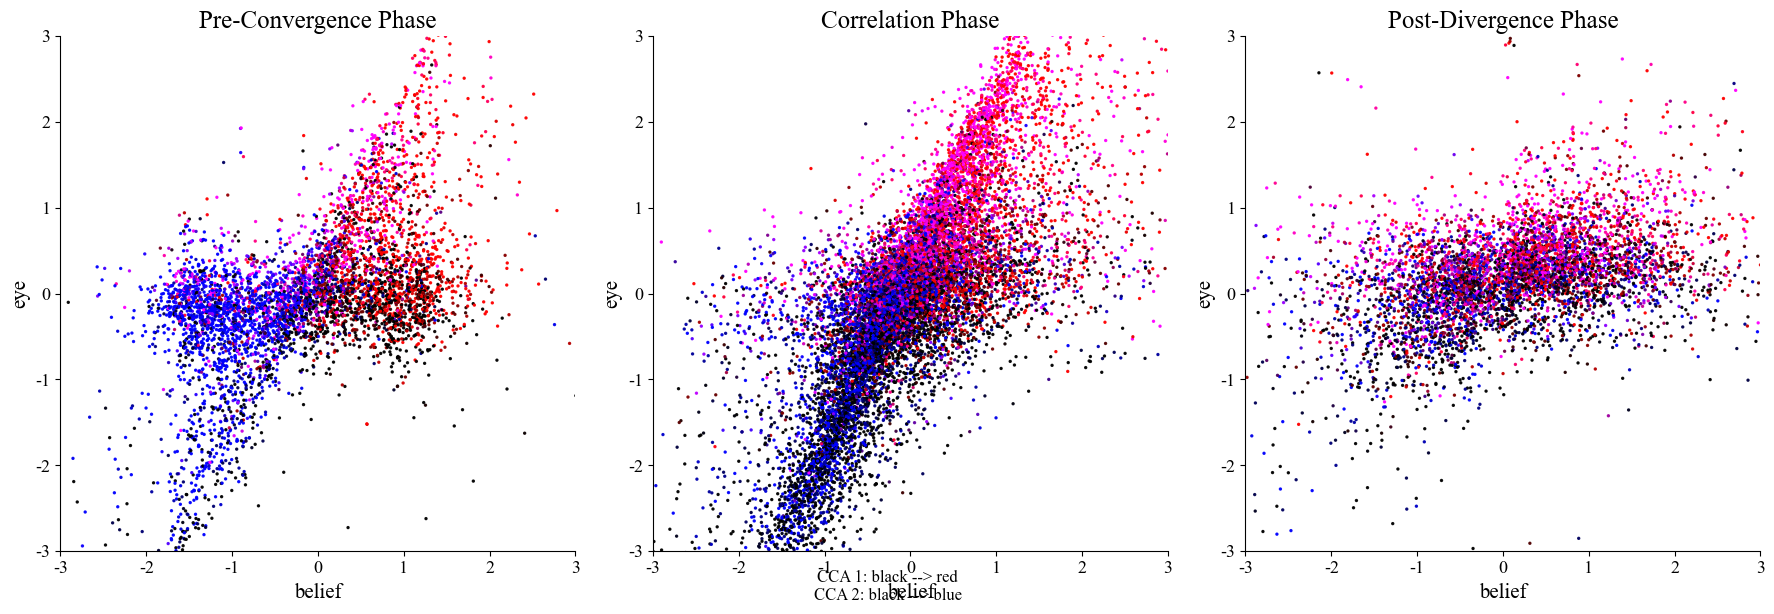

Points in pre-convergence phase: 5496
Points in correlation phase: 13452
Points in post-divergence phase: 5695


In [425]:
# Assuming you have:
# - belief_arrays and eye_arrays (your lists of signal arrays)
# - neural_data (the neural activity data)
# - detected_phases (from your find_correlation_phases function)

stats = plot_three_phases_cca(belief_arrays, eye_arrays, neural_data, detected_phases)
print(f"Points in pre-convergence phase: {stats['pre_count']}")
print(f"Points in correlation phase: {stats['correlation_count']}")
print(f"Points in post-divergence phase: {stats['post_count']}")

# nenw

In [426]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def find_phases_for_short_trials(belief_arrays, eye_arrays, min_points=1, correlation_factor=1.05, early_detection=True):
    """
    Find phases in very short trials with improved sensitivity to early convergence.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    min_points : int
        Minimum number of points required for correlation calculation
    correlation_factor : float
        Factor to determine significant correlation differences between segments
    early_detection : bool
        If True, bias toward detecting convergence earlier in trials
        
    Returns:
    --------
    points : numpy.ndarray
        Array of shape (n_trials, 2) containing [start_corr_idx, end_corr_idx] for each trial
    """
    n_trials = len(belief_arrays)
    results = np.zeros((n_trials, 2), dtype=int)
    
    for trial in range(n_trials):
        b = belief_arrays[trial]
        e = eye_arrays[trial]
        n_points = len(b)
        
        # For very short trials, we can't use rolling windows effectively
        if n_points < 2*min_points:
            # Too short to detect different phases - use default values
            results[trial, 0] = 0
            results[trial, 1] = max(0, n_points - 1)
            continue
        
        # Use more segments for finer detection
        if early_detection and n_points >= 5:
            # Use more segments for better resolution
            n_segments = min(5, n_points // min_points)
            segment_size = n_points // n_segments
            
            # Calculate correlation in each segment
            segment_corrs = []
            for i in range(n_segments):
                start = i * segment_size
                end = min(start + segment_size, n_points)
                if end - start >= min_points:
                    try:
                        r, _ = stats.pearsonr(b[start:end], e[start:end])
                        segment_corrs.append(abs(r))
                    except:
                        segment_corrs.append(0)
                else:
                    segment_corrs.append(0)
            
            # Look for the first significant rise in correlation
            for i in range(1, len(segment_corrs)):
                if segment_corrs[i] > correlation_factor * max(0.1, segment_corrs[0]):
                    # Found convergence point - start of this segment
                    conv_idx = i * segment_size
                    break
            else:
                # No clear convergence found, use early default
                conv_idx = min(int(0.1 * n_points), n_points // 3)
            
            # Look for divergence after convergence
            for i in range(len(segment_corrs)-1, 0, -1):
                if segment_corrs[i] < segment_corrs[i-1] / correlation_factor:
                    # Found divergence - start of this segment
                    div_idx = i * segment_size
                    break
            else:
                # No clear divergence found, use late default
                div_idx = max(int(0.7 * n_points), 2 * n_points // 3)
            
            results[trial, 0] = min(conv_idx, n_points - 1)
            results[trial, 1] = min(div_idx, n_points - 1)
            
        else:
            # Original approach - divide into thirds
            third = max(min_points, n_points // 3)
            
            # Calculate correlations for each segment
            if third < min_points:
                # Fall back to simple division if segments are too small
                results[trial, 0] = third
                results[trial, 1] = 2 * third
                continue
            
            try:
                # Early segment
                early_corr = abs(stats.pearsonr(b[:third], e[:third])[0])
                
                # Middle segment
                middle_start = (n_points - third) // 2
                middle_corr = abs(stats.pearsonr(
                    b[middle_start:middle_start+third], 
                    e[middle_start:middle_start+third]
                )[0])
                
                # Late segment
                late_corr = abs(stats.pearsonr(b[-third:], e[-third:])[0])
                
                # Determine phase boundaries based on correlation patterns
                correlations = [early_corr, middle_corr, late_corr]
                
                # If middle has highest correlation, that's our correlation phase
                if correlations.index(max(correlations)) == 1:
                    results[trial, 0] = middle_start
                    results[trial, 1] = middle_start + third - 1
                # If correlation increases and then decreases
                elif early_corr < middle_corr > late_corr:
                    results[trial, 0] = third
                    results[trial, 1] = n_points - third - 1
                # If correlation is generally increasing
                elif early_corr < middle_corr < late_corr:
                    results[trial, 0] = middle_start
                    results[trial, 1] = n_points - 1
                # If correlation is generally decreasing
                elif early_corr > middle_corr > late_corr:
                    results[trial, 0] = 0
                    results[trial, 1] = middle_start + third - 1
                else:
                    # Default to middle third if no clear pattern
                    results[trial, 0] = third
                    results[trial, 1] = n_points - third - 1
            except:
                # Handle statistical exceptions by using simple thirds
                results[trial, 0] = third
                results[trial, 1] = n_points - third - 1
    
    return results
def visualize_short_trials(belief_arrays, eye_arrays, detected_phases, trials_to_plot=None):
    """
    Visualize the short trials with their detected phases.
    """
    n_trials = len(belief_arrays)
    
    if trials_to_plot is None:
        trials_to_plot = range(min(n_trials, 5))
    
    for idx in trials_to_plot:
        if idx >= n_trials:
            continue
            
        b = belief_arrays[idx]
        e = eye_arrays[idx]
        n_points = len(b)
        
        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Plot the signals
        ax.plot(range(n_points), b, 'b-', label='Belief')
        ax.plot(range(n_points), e, 'r-', label='Eye')
        
        # Highlight the detected phases
        start_idx = detected_phases[idx, 0]
        end_idx = detected_phases[idx, 1]
        
        # Pre-correlation phase
        if start_idx > 0:
            ax.axvspan(0, start_idx-0.5, alpha=0.2, color='blue', label='Pre-corr')
        
        # Correlation phase
        ax.axvspan(start_idx-0.5, end_idx+0.5, alpha=0.2, color='green', label='Correlation')
        
        # Post-correlation phase
        if end_idx < n_points-1:
            ax.axvspan(end_idx+0.5, n_points-1, alpha=0.2, color='red', label='Post-corr')
        
        ax.set_title(f'Trial {idx+1}: {n_points} points')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()



def plot_three_phases_by_time(belief_arrays, eye_arrays, detected_phases):
    """
    Create three separate scatter plots for pre-convergence, correlation, and post-divergence phases,
    colored by time ratio within each trial.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    detected_phases : numpy.ndarray
        Array of shape (n_trials, 2) with detected convergence/divergence points
    """
    # First, convert the list of arrays into flat arrays with phase and time information
    all_belief = []
    all_eye = []
    all_time_ratio = []
    phase_labels = []  # 0: pre, 1: corr, 2: post
    
    for trial_idx in range(len(belief_arrays)):
        b = belief_arrays[trial_idx]
        e = eye_arrays[trial_idx]
        n_points = len(b)
        
        # Create time ratio for this trial
        time_ratio = np.linspace(0, 1, n_points)
        
        if trial_idx < len(detected_phases):
            start_idx, end_idx = detected_phases[trial_idx]
            
            # Ensure boundaries are valid
            start_idx = max(0, min(start_idx, n_points-1))
            end_idx = max(start_idx, min(end_idx, n_points-1))
            
            # Add pre-correlation phase points
            for i in range(0, start_idx):
                all_belief.append(b[i])
                all_eye.append(e[i])
                all_time_ratio.append(time_ratio[i])
                phase_labels.append(0)  # Pre-correlation
            
            # Add correlation phase points
            for i in range(start_idx, end_idx+1):
                all_belief.append(b[i])
                all_eye.append(e[i])
                all_time_ratio.append(time_ratio[i])
                phase_labels.append(1)  # Correlation
            
            # Add post-correlation phase points
            for i in range(end_idx+1, n_points):
                all_belief.append(b[i])
                all_eye.append(e[i])
                all_time_ratio.append(time_ratio[i])
                phase_labels.append(2)  # Post-correlation
    
    # Convert to numpy arrays for easier manipulation
    all_belief = np.array(all_belief)
    all_eye = np.array(all_eye)
    all_time_ratio = np.array(all_time_ratio)
    phase_labels = np.array(phase_labels)
    
    # Create the related_taskvar array
    related_taskvar = np.column_stack((all_belief, all_eye))
    
    # Apply filtering for outliers
    mask = (related_taskvar > -4) & (related_taskvar < 4)
    mask = mask[:,0] & mask[:,1]
    
    related_taskvar = related_taskvar[mask]
    all_time_ratio = all_time_ratio[mask]
    phase_labels = phase_labels[mask]
    
    # Create indices for each phase
    pre_idx = np.where(phase_labels == 0)[0]
    corr_idx = np.where(phase_labels == 1)[0]
    post_idx = np.where(phase_labels == 2)[0]
    
    # Create the three scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Pre-convergence
    if len(pre_idx) > 0:
        sc1 = axes[0].scatter(
            related_taskvar[pre_idx, 0], 
            related_taskvar[pre_idx, 1], 
            c=all_time_ratio[pre_idx], 
            cmap='viridis', 
            s=3, 
            alpha=0.7
        )
        plt.colorbar(sc1, ax=axes[0], label='Time ratio in trial')
    axes[0].set_title(f'Pre-Convergence Phase ({len(pre_idx)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Plot 2: Correlation period
    if len(corr_idx) > 0:
        sc2 = axes[1].scatter(
            related_taskvar[corr_idx, 0], 
            related_taskvar[corr_idx, 1], 
            c=all_time_ratio[corr_idx], 
            cmap='viridis', 
            s=3, 
            alpha=0.7
        )
        plt.colorbar(sc2, ax=axes[1], label='Time ratio in trial')
    axes[1].set_title(f'Correlation Phase ({len(corr_idx)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # Plot 3: Post-divergence
    if len(post_idx) > 0:
        sc3 = axes[2].scatter(
            related_taskvar[post_idx, 0], 
            related_taskvar[post_idx, 1], 
            c=all_time_ratio[post_idx], 
            cmap='viridis', 
            s=3, 
            alpha=0.7
        )
        plt.colorbar(sc3, ax=axes[2], label='Time ratio in trial')
    axes[2].set_title(f'Post-Divergence Phase ({len(post_idx)} points)')
    axes[2].set_xlabel('belief')
    axes[2].set_ylabel('eye')
    axes[2].set_xlim(-3, 3)
    axes[2].set_ylim(-3, 3)
    axes[2].set_aspect('equal')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.suptitle('Belief vs Eye Relationship by Phase (Colored by Time Ratio)', y=1.02)
    plt.show()
    
    # Return statistics
    return {
        'pre_count': len(pre_idx),
        'correlation_count': len(corr_idx),
        'post_count': len(post_idx),
        'total_points': len(related_taskvar)
    }


def plot_three_phases_by_cca(belief_arrays, eye_arrays, neural_data, detected_phases):
    """
    Create three separate scatter plots for pre-convergence, correlation, and post-divergence phases,
    colored by CCA dimensions matching the reference code.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    neural_data : numpy.ndarray
        Neural data with shape (n_samples, n_neurons)
    detected_phases : numpy.ndarray
        Array of shape (n_trials, 2) with detected convergence/divergence points
    """
    # Collect all belief/eye data and corresponding trial indices/time points
    all_belief = []
    all_eye = []
    trial_indices = []
    time_indices = []
    
    for trial_idx in range(len(belief_arrays)):
        b = belief_arrays[trial_idx]
        e = eye_arrays[trial_idx]
        
        for time_idx in range(len(b)):
            all_belief.append(b[time_idx])
            all_eye.append(e[time_idx])
            trial_indices.append(trial_idx)
            time_indices.append(time_idx)
    
    # Convert to numpy arrays
    all_belief = np.array(all_belief)
    all_eye = np.array(all_eye)
    trial_indices = np.array(trial_indices)
    time_indices = np.array(time_indices)
    
    # Create behavioral variables array
    related_taskvar = np.column_stack((all_belief, all_eye))
    
    # Filter outliers
    # mask = (related_taskvar > -4) & (related_taskvar < 4)
    # mask = mask[:, 0] & mask[:, 1]
    
    # related_taskvar = related_taskvar[mask]
    # trial_indices = trial_indices[mask]
    # time_indices = time_indices[mask]
    

    # # Apply the same filter to neural data
    # neural_data = neural_data[mask]
    
    # Run CCA (exactly as in the reference code)
    try:
        from sklearn.cross_decomposition import CCA
        cca = CCA(n_components=2)
        cca_neural, cca_be = cca.fit_transform(neural_data, related_taskvar)
        
        # Get CCA components
        t1, t2 = cca_neural[:, 0], cca_neural[:, 1]
        
        # Generate RGB values exactly as in reference
        c1 = np.array([1, 0, 0])  # Red
        c2 = np.array([0, 0, 1])  # Blue
        rgb_values = np.zeros((len(t1), 3))
        rgb_values[:, [0, 2]] = 0.25  # Base color
        
        rgb_values += (c1[:, None] * t1).T
        rgb_values += (c2[:, None] * t2).T
        
        rgb_values = rgb_values.clip(0, 1)
        hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
        cca_success = True
        
    except Exception as e:
        print(f"CCA failed: {e}")
        hex_colors = ['black'] * len(related_taskvar)
        cca_success = False
    
    # Create phase labels
    phase_labels = np.zeros(len(trial_indices), dtype=int)
    
    # Assign phases based on detected_phases
    for i, (trial_idx, time_idx) in enumerate(zip(trial_indices, time_indices)):
        if trial_idx < len(detected_phases):
            start_idx, end_idx = detected_phases[trial_idx]
            
            if time_idx < start_idx:
                phase_labels[i] = 0  # Pre-convergence
            elif start_idx <= time_idx <= end_idx:
                phase_labels[i] = 1  # Correlation
            else:
                phase_labels[i] = 2  # Post-divergence
    
    # Get indices for each phase
    pre_idx = np.where(phase_labels == 0)[0]
    corr_idx = np.where(phase_labels == 1)[0]
    post_idx = np.where(phase_labels == 2)[0]
    
    # Create three plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Pre-convergence
    if len(pre_idx) > 0:
        axes[0].scatter(
            related_taskvar[pre_idx, 0], 
            related_taskvar[pre_idx, 1],
            c=[hex_colors[i] for i in pre_idx] if cca_success else 'blue',
            s=1, alpha=0.5
        )
    axes[0].set_title(f'Pre-Convergence Phase ({len(pre_idx)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Plot 2: Correlation
    if len(corr_idx) > 0:
        axes[1].scatter(
            related_taskvar[corr_idx, 0], 
            related_taskvar[corr_idx, 1],
            c=[hex_colors[i] for i in corr_idx] if cca_success else 'green',
            s=1, alpha=0.5
        )
    axes[1].set_title(f'Correlation Phase ({len(corr_idx)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # Plot 3: Post-divergence
    if len(post_idx) > 0:
        axes[2].scatter(
            related_taskvar[post_idx, 0], 
            related_taskvar[post_idx, 1],
            c=[hex_colors[i] for i in post_idx] if cca_success else 'red',
            s=1, alpha=0.5
        )
    axes[2].set_title(f'Post-Divergence Phase ({len(post_idx)} points)')
    axes[2].set_xlabel('belief')
    axes[2].set_ylabel('eye')
    axes[2].set_xlim(-3, 3)
    axes[2].set_ylim(-3, 3)
    axes[2].set_aspect('equal')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    # Add title and legend
    if cca_success:
        fig.suptitle('Belief vs Eye Relationship by Phase', y=0.98)
        fig.text(0.5, 0.01, 'CCA 1: black --> red\nCCA 2: black --> blue', 
                ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print total number of data points
    total_points = len(related_taskvar)
    print('num data points', total_points)
    
    # Return statistics
    return {
        'pre_count': len(pre_idx),
        'correlation_count': len(corr_idx),
        'post_count': len(post_idx),
        'total_points': total_points
    }


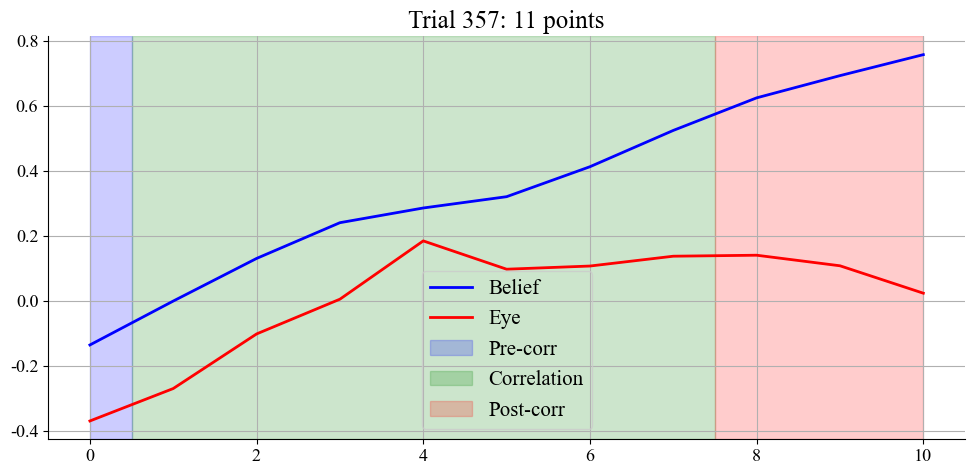

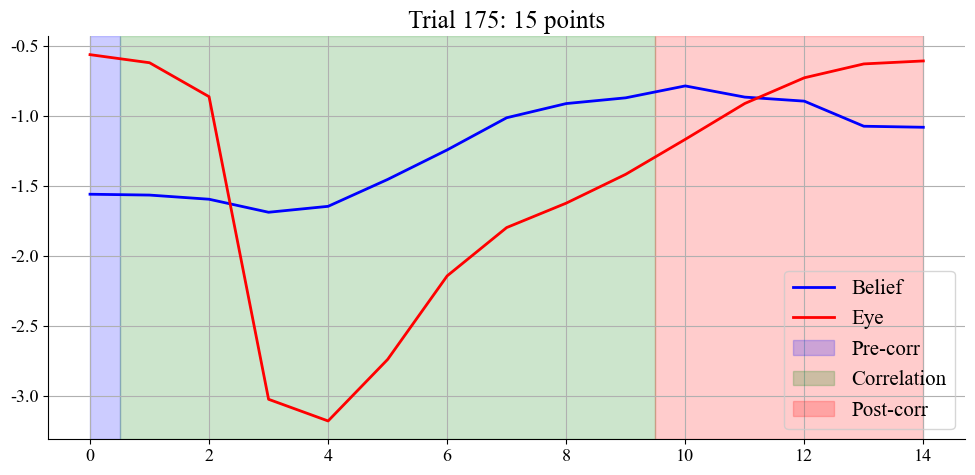

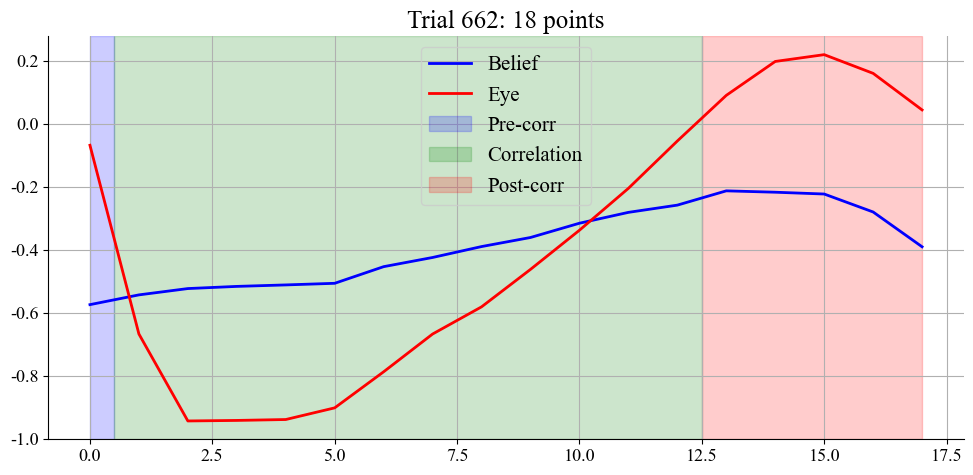

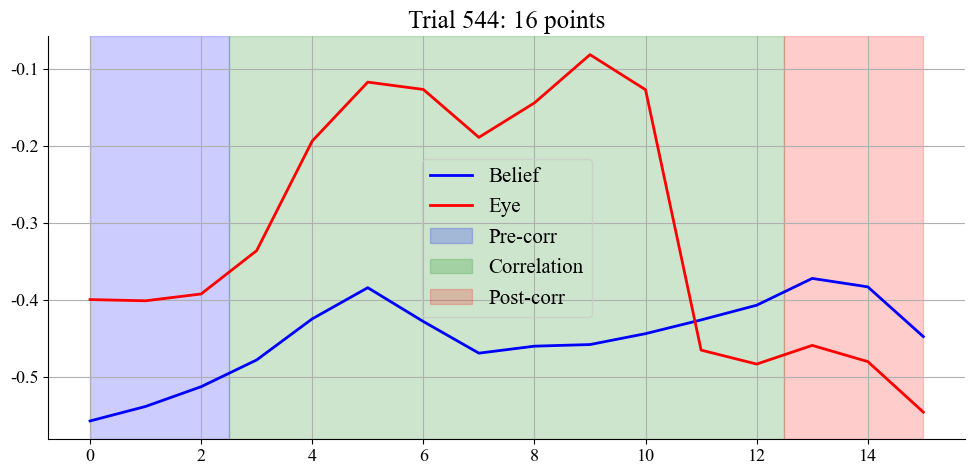

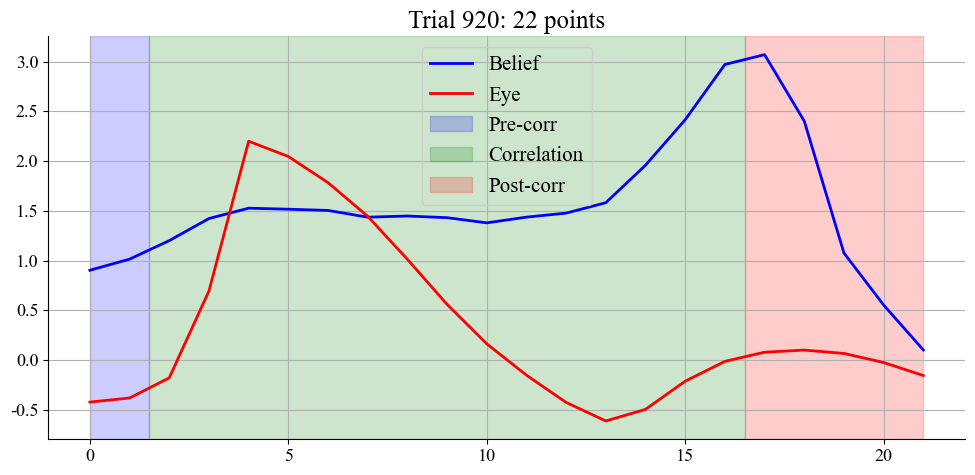

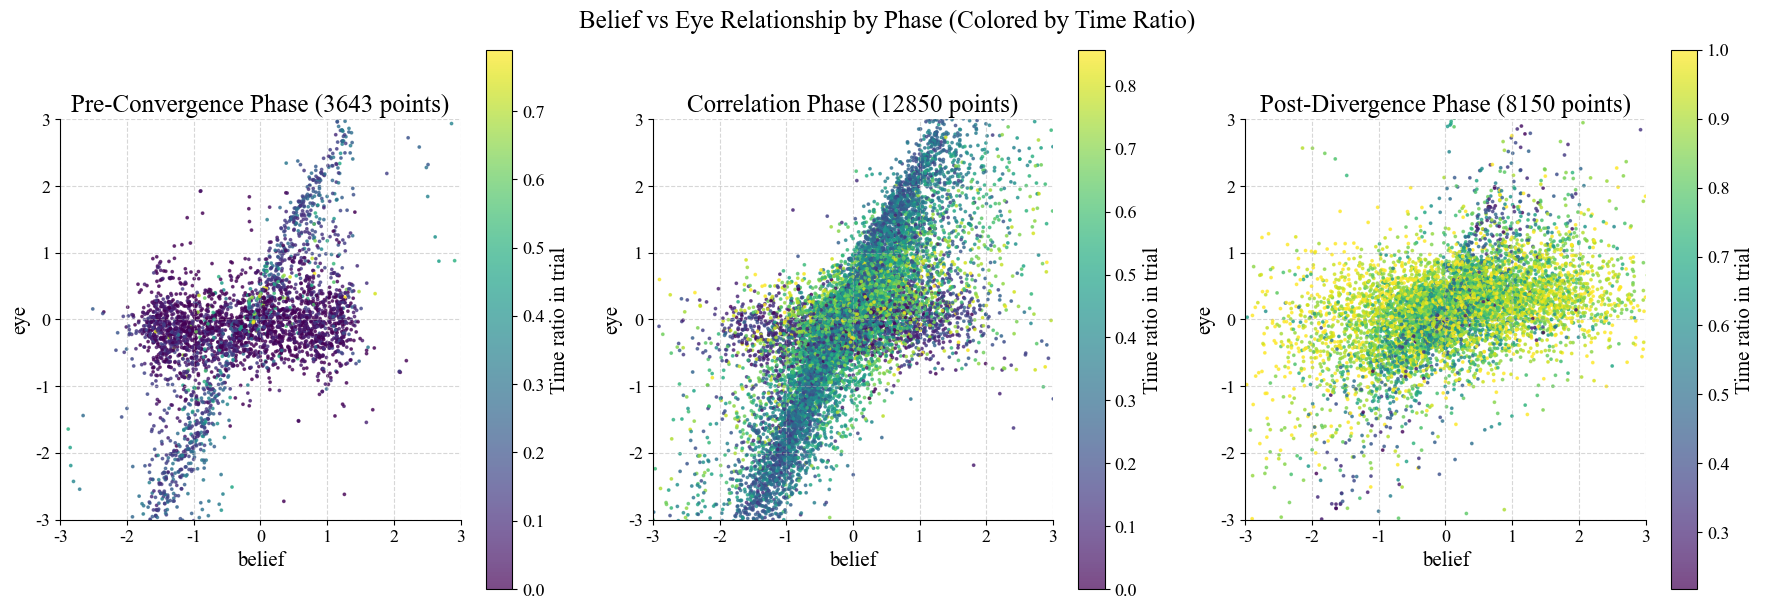

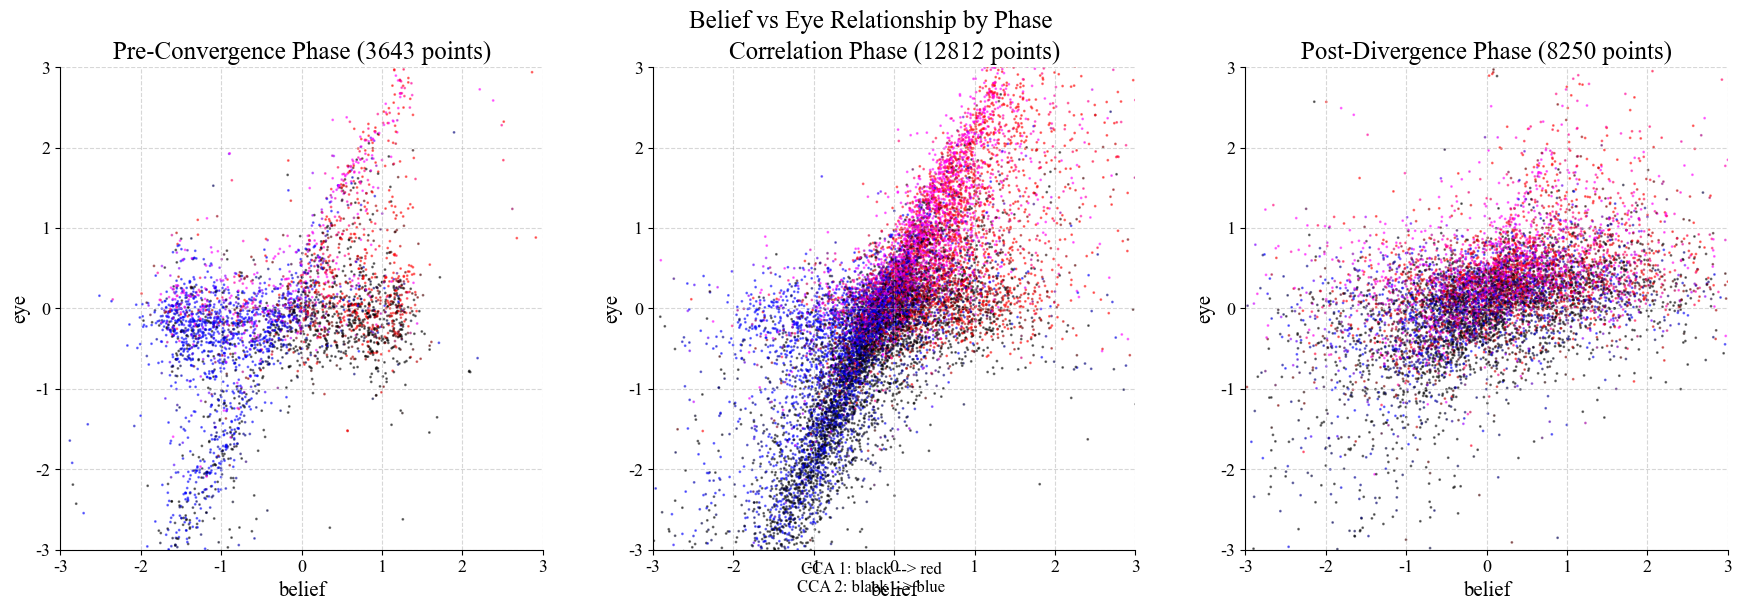

num data points 24705
Time ratio coloring statistics:
Pre-convergence: 3643 points
Correlation: 12850 points
Post-divergence: 8150 points

CCA coloring statistics:
Pre-convergence: 3643 points
Correlation: 12812 points
Post-divergence: 8250 points


In [427]:
# Detect phases using the approach optimized for short trials
detected_phases = find_phases_for_short_trials(belief_arrays, eye_arrays, 
                                             min_points=1,
                                             correlation_factor=1.05, 
                                             early_detection=True)
# Visualize some individual trials to verify the detection
visualize_short_trials(belief_arrays, eye_arrays, detected_phases, trials_to_plot=np.random.choice(1000,5))

stats_time = plot_three_phases_by_time(belief_arrays, eye_arrays, detected_phases)

# For CCA dimension coloring
stats_cca = plot_three_phases_by_cca(belief_arrays, eye_arrays, neural_data, detected_phases)

# Print statistics
print("Time ratio coloring statistics:")
print(f"Pre-convergence: {stats_time['pre_count']} points")
print(f"Correlation: {stats_time['correlation_count']} points")
print(f"Post-divergence: {stats_time['post_count']} points")

print("\nCCA coloring statistics:")
print(f"Pre-convergence: {stats_cca['pre_count']} points")
print(f"Correlation: {stats_cca['correlation_count']} points")
print(f"Post-divergence: {stats_cca['post_count']} points")

# new, just use diff, no 1 trial 3 part

In [120]:
timedf.timer

0         0
1         1
2         2
3         3
4         4
         ..
24696     7
24697     8
24698     9
24699    10
24700    11
Name: timer, Length: 23201, dtype: int64

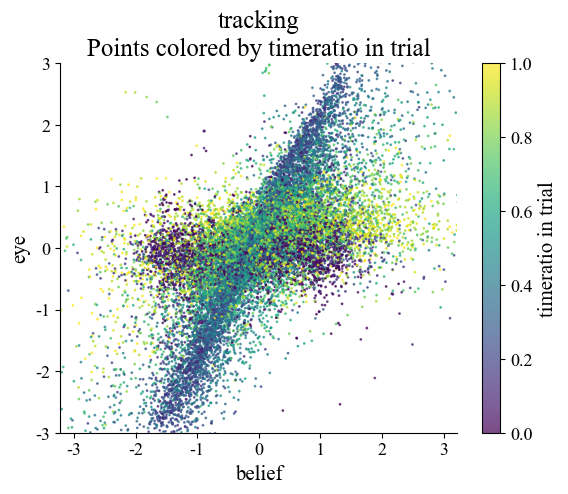

In [129]:
# tracking 
thisdf=timedf[(timedf.fullon==0)]

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

# Extract timer values and apply the same mask
timer_values = thisdf.timeratio.to_numpy()[mask]
# Normalize timer values to 0-1 range for coloring
timer_norm = (timer_values - np.min(timer_values)) / (np.max(timer_values) - np.min(timer_values))

cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)

thisx,thisy=related_taskvar[:,0], related_taskvar[:,1]

# Use timer values for coloring
plt.scatter(thisx, thisy, c=timer_values, cmap='viridis', s=1, alpha=0.7)
plt.colorbar(label='timeratio in trial')

# quickallspine(plt.gca())
plt.xlabel('belief')
plt.ylabel('eye')
plt.axis('equal')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f'tracking\nPoints colored by timeratio in trial')
plt.show()

# new, soft threshold based on abs diff and derivative diff.

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cross_decomposition import CCA

def classify_correlation_points(belief_arrays, eye_arrays, correlation_threshold=0.3, derivative_weight=0.4, 
                              normalization_percentile=95):
    """
    Classify data points as either in correlation or out of correlation
    based on a mixed metric of absolute difference and derivatives.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    all_belief : numpy.ndarray
        Array of all belief values
    all_eye : numpy.ndarray
        Array of all eye values
    all_time_ratio : numpy.ndarray
        Array of time ratios for all points
    in_correlation : numpy.ndarray
        Boolean mask indicating which points are in correlation
    valid_mask : numpy.ndarray
        Boolean mask for the original flattened arrays indicating valid points
    """
    # Collect all data points and their derivatives
    all_belief = []
    all_eye = []
    all_time_ratio = []
    all_belief_derivatives = []
    all_eye_derivatives = []
    all_trial_indices = []
    
    for trial_idx in range(len(belief_arrays)):
        b = belief_arrays[trial_idx]
        e = eye_arrays[trial_idx]
        n_points = len(b)
        
        # Skip trials that are too short for derivative calculation
        if n_points < 3:
            print(f"Skipping trial {trial_idx} with only {n_points} points")
            continue
        
        # Generate time ratio for this trial
        time_ratio = np.linspace(0, 1, n_points)
        
        # Calculate derivatives (using central difference)
        # Pad the first and last points to maintain array size
        belief_deriv = np.zeros_like(b)
        eye_deriv = np.zeros_like(e)
        
        # Central difference for interior points
        belief_deriv[1:-1] = (b[2:] - b[:-2]) / 2
        eye_deriv[1:-1] = (e[2:] - e[:-2]) / 2
        
        # Forward and backward differences for endpoints
        belief_deriv[0] = b[1] - b[0]
        belief_deriv[-1] = b[-1] - b[-2]
        eye_deriv[0] = e[1] - e[0]
        eye_deriv[-1] = e[-1] - e[-2]
        
        # Add all points from this trial
        all_belief.extend(b)
        all_eye.extend(e)
        all_time_ratio.extend(time_ratio)
        all_belief_derivatives.extend(belief_deriv)
        all_eye_derivatives.extend(eye_deriv)
        all_trial_indices.extend([trial_idx] * n_points)
    
    # Convert to numpy arrays
    all_belief = np.array(all_belief)
    all_eye = np.array(all_eye)
    all_time_ratio = np.array(all_time_ratio)
    all_belief_derivatives = np.array(all_belief_derivatives)
    all_eye_derivatives = np.array(all_eye_derivatives)
    all_trial_indices = np.array(all_trial_indices)
    
    # Create mask for valid points (not outliers)
    valid_mask = (all_belief > -4) & (all_belief < 4) & (all_eye > -4) & (all_eye < 4)
    
    # Apply mask
    filtered_belief = all_belief[valid_mask]
    filtered_eye = all_eye[valid_mask]
    filtered_time_ratio = all_time_ratio[valid_mask]
    filtered_belief_derivatives = all_belief_derivatives[valid_mask]
    filtered_eye_derivatives = all_eye_derivatives[valid_mask]
    filtered_trial_indices = all_trial_indices[valid_mask]
    
    # Compute absolute difference score (normalized to percentile)
    abs_diff = np.abs(filtered_belief - filtered_eye)
    norm_value = np.percentile(abs_diff, normalization_percentile)
    abs_diff_score = abs_diff / norm_value
    abs_diff_score = np.clip(abs_diff_score, 0, 1)  # Clip to [0,1]
    
    # Compute derivative agreement score
    # 1. Normalize derivatives
    belief_deriv_std = np.std(filtered_belief_derivatives) or 1
    eye_deriv_std = np.std(filtered_eye_derivatives) or 1
    belief_deriv_norm = filtered_belief_derivatives / belief_deriv_std
    eye_deriv_norm = filtered_eye_derivatives / eye_deriv_std
    
    # 2. Calculate cosine similarity (direction agreement)
    # Apply a non-linear transformation to make the score more discriminative
    deriv_product = belief_deriv_norm * eye_deriv_norm
    
    # 3. Transform to a score between 0 (good agreement) and 1 (poor agreement)
    # Using squared transformation to penalize opposing directions more
    deriv_score = ((1 - deriv_product) * 0.5) ** 0.5
    
    # Combine scores with weighting
    combined_metric = (1 - derivative_weight) * abs_diff_score + derivative_weight * deriv_score
    
    # Determine correlation based on combined metric
    in_correlation = combined_metric < correlation_threshold
    
    # Print summary statistics
    print(f"Total points: {len(filtered_belief)}")
    print(f"In correlation: {np.sum(in_correlation)} ({np.sum(in_correlation)/len(filtered_belief)*100:.1f}%)")
    print(f"Out of correlation: {np.sum(~in_correlation)} ({np.sum(~in_correlation)/len(filtered_belief)*100:.1f}%)")
    print(f"Threshold: {correlation_threshold}, Derivative weight: {derivative_weight}")
    print(f"Normalization percentile: {normalization_percentile}")
    
    return filtered_belief, filtered_eye, filtered_time_ratio, in_correlation, valid_mask

def plot_by_time_ratio(belief_arrays, eye_arrays, correlation_threshold=0.3, derivative_weight=0.4, 
                      normalization_percentile=95):
    """
    Create two scatter plots: in correlation and out of correlation,
    colored by time ratio in trial.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    dict
        Statistics about the number of points in correlation and out of correlation
    """
    # Classify data points
    belief, eye, time_ratio, in_correlation, _ = classify_correlation_points(
        belief_arrays, eye_arrays, correlation_threshold, derivative_weight, normalization_percentile)
    
    # Create two sets of points
    corr_belief = belief[in_correlation]
    corr_eye = eye[in_correlation]
    corr_time = time_ratio[in_correlation]
    
    non_corr_belief = belief[~in_correlation]
    non_corr_eye = eye[~in_correlation]
    non_corr_time = time_ratio[~in_correlation]
    
    # Fit a linear regression model to visualize the relationship
    slope, intercept, r_value, p_value, std_err = stats.linregress(belief, eye)
    regression_x = np.linspace(-3, 3, 100)
    regression_y = slope * regression_x + intercept
    
    # Create the two scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: In Correlation
    sc1 = axes[0].scatter(
        corr_belief, corr_eye, 
        c=corr_time, cmap='viridis', 
        s=1, alpha=0.7
    )
    axes[0].plot(regression_x, regression_y, 'r-', linewidth=2, 
                 label=f'y = {slope:.2f}x + {intercept:.2f} (r² = {r_value**2:.2f})')
    axes[0].set_title(f'In Correlation ({len(corr_belief)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')
    plt.colorbar(sc1, ax=axes[0], label='Time ratio in trial')
    
    # Plot 2: Out of Correlation
    sc2 = axes[1].scatter(
        non_corr_belief, non_corr_eye, 
        c=non_corr_time, cmap='viridis', 
        s=1, alpha=0.7
    )
    axes[1].plot(regression_x, regression_y, 'r-', linewidth=2)
    axes[1].set_title(f'Out of Correlation ({len(non_corr_belief)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc2, ax=axes[1], label='Time ratio in trial')
    
    plt.tight_layout()
    plt.suptitle(f'Belief vs Eye Relationship (thresh={correlation_threshold}, deriv_w={derivative_weight}, norm_p={normalization_percentile})', 
                y=1.02, fontsize=11)
    plt.show()
    
    # Return statistics
    return {
        'correlation_count': len(corr_belief),
        'non_correlation_count': len(non_corr_belief),
        'total_points': len(belief)
    }

def plot_by_cca(belief_arrays, eye_arrays, neural_data, correlation_threshold=0.3, derivative_weight=0.4,
              normalization_percentile=95):
    """
    Create two scatter plots: in correlation and out of correlation,
    colored by CCA components.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    neural_data : neural data for CCA
        Neural data for the CCA analysis
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    dict
        Statistics about the number of points in correlation and out of correlation
    """
    # Classify data points
    belief, eye, _, in_correlation, valid_mask = classify_correlation_points(
        belief_arrays, eye_arrays, correlation_threshold, derivative_weight, normalization_percentile)
    
    # Create behavioral variables array
    related_taskvar = np.column_stack((belief, eye))
    
    # Run CCA
 
    cca = CCA(n_components=2)
   
    neural_data = [item for item, include in zip(neural_data, valid_mask) if include]

    cca_neural, cca_be = cca.fit_transform(neural_data, related_taskvar)
    
    # Get CCA components and behavioral variables
    thisx, thisy = related_taskvar[:, 0], related_taskvar[:, 1]
    t1, t2 = cca_neural[:, 0], cca_neural[:, 1]
    
    # Generate RGB values
    c1 = np.array([1, 0, 0])  # Red
    c2 = np.array([0, 0, 1])  # Blue
    rgb_values = np.zeros((len(t1), 3))
    rgb_values[:, [0, 2]] = 0.25  # Base color
    
    # Apply color mapping as per reference code
    rgb_values += (c1[:, None] * t1).T
    rgb_values += (c2[:, None] * t2).T
    
    rgb_values = rgb_values.clip(0, 1)
    hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
    cca_success = True

    
    # Fit a linear regression model to visualize the relationship
    slope, intercept, r_value, p_value, std_err = stats.linregress(belief, eye)
    regression_x = np.linspace(-3, 3, 100)
    regression_y = slope * regression_x + intercept
    
    # Create the two scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: In Correlation
    if np.any(in_correlation):
        axes[0].scatter(
            belief[in_correlation], eye[in_correlation], 
            c=[hex_colors[i] for i in np.where(in_correlation)[0]] if cca_success else 'blue', 
            s=1, alpha=0.5
        )
    axes[0].plot(regression_x, regression_y, 'r-', linewidth=2, 
                 label=f'y = {slope:.2f}x + {intercept:.2f} (r² = {r_value**2:.2f})')
    axes[0].set_title(f'In Correlation ({np.sum(in_correlation)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')
    
    # Plot 2: Out of Correlation
    if np.any(~in_correlation):
        axes[1].scatter(
            belief[~in_correlation], eye[~in_correlation], 
            c=[hex_colors[i] for i in np.where(~in_correlation)[0]] if cca_success else 'red', 
            s=1, alpha=0.5
        )
    axes[1].plot(regression_x, regression_y, 'r-', linewidth=2)
    axes[1].set_title(f'Out of Correlation ({np.sum(~in_correlation)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    if cca_success:
        fig.suptitle(f'Belief vs Eye Relationship (thresh={correlation_threshold}, deriv_w={derivative_weight}, norm_p={normalization_percentile})', 
                    y=0.98, fontsize=22)
        fig.text(0.5, 0.01, 'CCA 1: black --> red\nCCA 2: black --> blue', 
                ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print total number of data points
    total_points = len(belief)
    print('num data points', total_points)
    print(f'in correlation: {np.sum(in_correlation)} points ({np.sum(in_correlation)/total_points*100:.1f}%)')
    print(f'out of correlation: {np.sum(~in_correlation)} points ({np.sum(~in_correlation)/total_points*100:.1f}%)')
    
    # Return statistics
    return {
        'correlation_count': np.sum(in_correlation),
        'non_correlation_count': np.sum(~in_correlation),
        'total_points': total_points
    }

Total points: 24643
In correlation: 21589 (87.6%)
Out of correlation: 3054 (12.4%)
Threshold: 0.6, Derivative weight: 0.5
Normalization percentile: 95


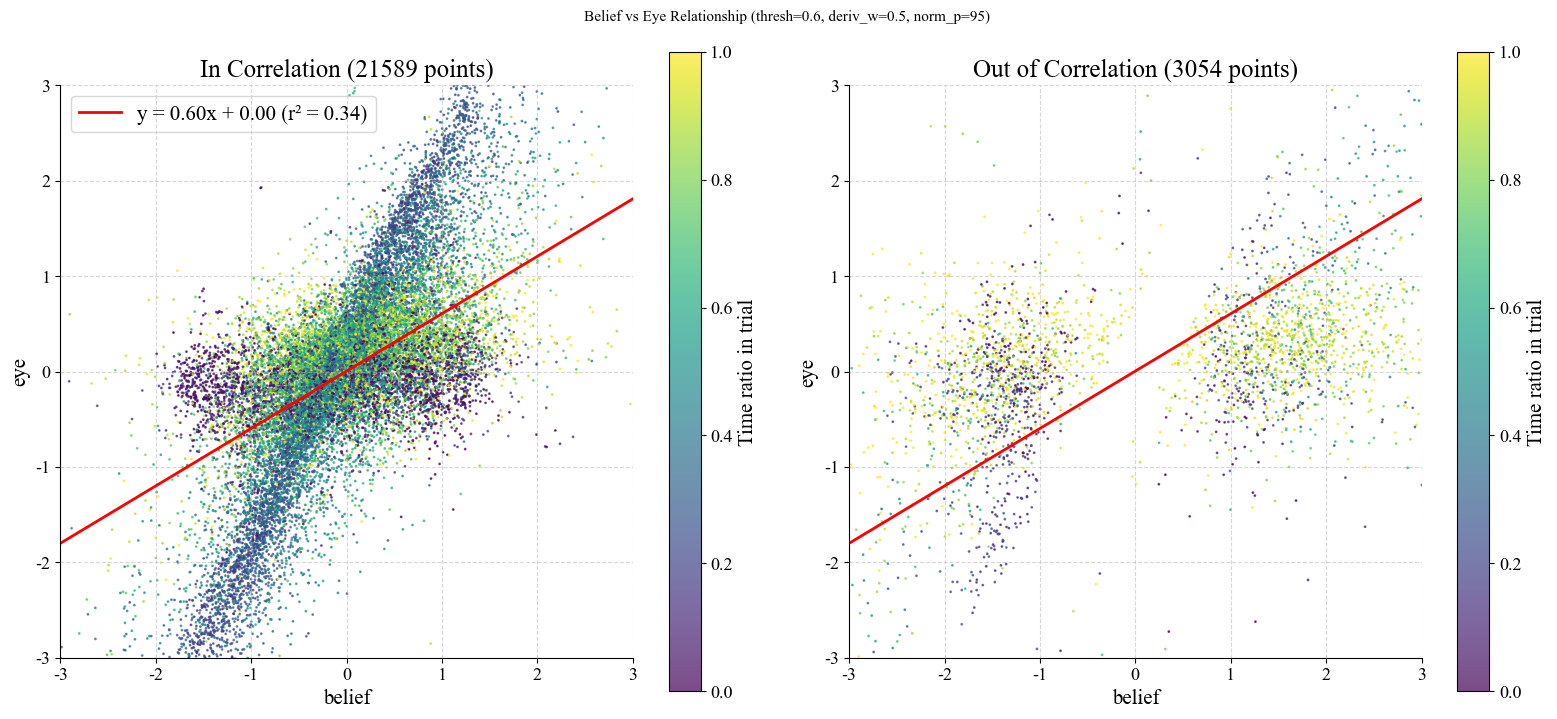

In [346]:
# For time ratio coloring
stats_time = plot_by_time_ratio(belief_arrays, eye_arrays, correlation_threshold=0.6, derivative_weight=0.5, 
                              normalization_percentile=95)

# For CCA coloring
# stats_cca = plot_by_cca(belief_arrays, eye_arrays, neural_data, correlation_threshold=0.4, derivative_weight=0.4, 
#                               normalization_percentile=95)

# new, hard y=2x cut.

In [444]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cross_decomposition import CCA

def classify_correlation_points(belief_arrays, eye_arrays, correlation_threshold=0.3, derivative_weight=0.4, 
                              normalization_percentile=95,scalar=3):
    """
    Classify data points as either in correlation or out of correlation
    based on their distance from the line eye = 2*belief and derivatives.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    all_belief : numpy.ndarray
        Array of all belief values
    all_eye : numpy.ndarray
        Array of all eye values
    all_time_ratio : numpy.ndarray
        Array of time ratios for all points
    in_correlation : numpy.ndarray
        Boolean mask indicating which points are in correlation
    valid_mask : numpy.ndarray
        Boolean mask for the original flattened arrays indicating valid points
    """
    # Collect all data points and their derivatives
    all_belief = []
    all_eye = []
    all_time_ratio = []
    all_belief_derivatives = []
    all_eye_derivatives = []
    all_trial_indices = []
    
    for trial_idx in range(len(belief_arrays)):
        b = belief_arrays[trial_idx]
        e = eye_arrays[trial_idx]
        n_points = len(b)
        
        # Skip trials that are too short for derivative calculation
        if n_points < 3:
            print(f"Skipping trial {trial_idx} with only {n_points} points")
            continue
        
        # Generate time ratio for this trial
        time_ratio = np.linspace(0, 1, n_points)
        
        # Calculate derivatives (using central difference)
        # Pad the first and last points to maintain array size
        belief_deriv = np.zeros_like(b)
        eye_deriv = np.zeros_like(e)
        
        # Central difference for interior points
        belief_deriv[1:-1] = (b[2:] - b[:-2]) / 2
        eye_deriv[1:-1] = (e[2:] - e[:-2]) / 2
        
        # Forward and backward differences for endpoints
        belief_deriv[0] = b[1] - b[0]
        belief_deriv[-1] = b[-1] - b[-2]
        eye_deriv[0] = e[1] - e[0]
        eye_deriv[-1] = e[-1] - e[-2]
        
        # Add all points from this trial
        all_belief.extend(b)
        all_eye.extend(e)
        all_time_ratio.extend(time_ratio)
        all_belief_derivatives.extend(belief_deriv)
        all_eye_derivatives.extend(eye_deriv)
        all_trial_indices.extend([trial_idx] * n_points)
    
    # Convert to numpy arrays
    all_belief = np.array(all_belief)
    all_eye = np.array(all_eye)
    all_time_ratio = np.array(all_time_ratio)
    all_belief_derivatives = np.array(all_belief_derivatives)
    all_eye_derivatives = np.array(all_eye_derivatives)
    all_trial_indices = np.array(all_trial_indices)
    
    # Create mask for valid points (not outliers)
    valid_mask = (all_belief > -4) & (all_belief < 4) & (all_eye > -4) & (all_eye < 4)
    
    # Apply mask
    filtered_belief = all_belief[valid_mask]
    filtered_eye = all_eye[valid_mask]
    filtered_time_ratio = all_time_ratio[valid_mask]
    filtered_belief_derivatives = all_belief_derivatives[valid_mask]
    filtered_eye_derivatives = all_eye_derivatives[valid_mask]
    filtered_trial_indices = all_trial_indices[valid_mask]
    
    # Compute distance from the line eye = 2*belief
    # The equation of the line is: eye = 2*belief
    # The perpendicular distance is: |eye - 2*belief|/sqrt(5)
    perpendicular_distance = np.abs(filtered_eye - scalar*filtered_belief)
    
    # Normalize the distance
    norm_value = np.percentile(perpendicular_distance, normalization_percentile)
    distance_score = perpendicular_distance / norm_value
    distance_score = np.clip(distance_score, 0, 1)  # Clip to [0,1]
    
    # Compute derivative alignment score
    # We want to check if the derivatives align with the slope of the main diagonal (slope = 2)
    # If eye_deriv ≈ 2*belief_deriv, they are aligned with the main diagonal
    deriv_alignment = np.abs(filtered_eye_derivatives - 2*filtered_belief_derivatives)
    
    # Normalize derivative alignment
    deriv_norm_value = np.percentile(deriv_alignment, normalization_percentile)
    deriv_score = deriv_alignment / deriv_norm_value
    deriv_score = np.clip(deriv_score, 0, 1)  # Clip to [0,1]
    
    # Combine scores with weighting
    combined_metric = (1 - derivative_weight) * distance_score + derivative_weight * deriv_score
    
    # Determine correlation based on combined metric
    in_correlation = combined_metric < correlation_threshold
    
    # Print summary statistics
    print(f"Total points: {len(filtered_belief)}")
    print(f"In correlation: {np.sum(in_correlation)} ({np.sum(in_correlation)/len(filtered_belief)*100:.1f}%)")
    print(f"Out of correlation: {np.sum(~in_correlation)} ({np.sum(~in_correlation)/len(filtered_belief)*100:.1f}%)")
    print(f"Threshold: {correlation_threshold}, Derivative weight: {derivative_weight}")
    print(f"Normalization percentile: {normalization_percentile}")
    
    return filtered_belief, filtered_eye, filtered_time_ratio, in_correlation, valid_mask

def plot_by_time_ratio(belief_arrays, eye_arrays, correlation_threshold=0.3, derivative_weight=0.4, 
                      normalization_percentile=95):
    """
    Create two scatter plots: in correlation and out of correlation,
    colored by time ratio in trial.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    dict
        Statistics about the number of points in correlation and out of correlation
    """
    # Classify data points
    belief, eye, time_ratio, in_correlation, _ = classify_correlation_points(
        belief_arrays, eye_arrays, correlation_threshold, derivative_weight, normalization_percentile)
    
    # Create two sets of points
    corr_belief = belief[in_correlation]
    corr_eye = eye[in_correlation]
    corr_time = time_ratio[in_correlation]
    
    non_corr_belief = belief[~in_correlation]
    non_corr_eye = eye[~in_correlation]
    non_corr_time = time_ratio[~in_correlation]
    
    # Fit a linear regression model to visualize the relationship
    slope, intercept, r_value, p_value, std_err = stats.linregress(belief, eye)
    regression_x = np.linspace(-3, 3, 100)
    regression_y = slope * regression_x + intercept
    
    # Create the two scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: In Correlation
    sc1 = axes[0].scatter(
        corr_belief, corr_eye, 
        c=corr_time, cmap='viridis', 
        s=1, alpha=0.7
    )
    # axes[0].plot(regression_x, regression_y, 'r-', linewidth=2, 
    #              label=f'y = {slope:.2f}x + {intercept:.2f} (r² = {r_value**2:.2f})')
    axes[0].set_title(f'In Correlation ({len(corr_belief)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')
    plt.colorbar(sc1, ax=axes[0], label='Time ratio in trial')
    
    # Plot 2: Out of Correlation
    sc2 = axes[1].scatter(
        non_corr_belief, non_corr_eye, 
        c=non_corr_time, cmap='viridis', 
        s=1, alpha=0.7
    )
    # axes[1].plot(regression_x, regression_y, 'r-', linewidth=2)
    axes[1].set_title(f'Out of Correlation ({len(non_corr_belief)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc2, ax=axes[1], label='Time ratio in trial')
    
    plt.tight_layout()
    plt.suptitle(f'Belief vs Eye Relationship (thresh={correlation_threshold}, deriv_w={derivative_weight}, norm_p={normalization_percentile})', 
                y=1.02, fontsize=11)
    plt.show()
    
    # Return statistics
    return {
        'correlation_count': len(corr_belief),
        'non_correlation_count': len(non_corr_belief),
        'total_points': len(belief)
    }




def plot_by_cca(belief_arrays, eye_arrays, neural_data, correlation_threshold=0.3, derivative_weight=0.4,
              normalization_percentile=95):
    """
    Create two scatter plots: in correlation and out of correlation,
    colored by CCA components.
    
    Parameters:
    -----------
    belief_arrays : list of numpy.ndarray
        List where each item is the belief signal for one trial
    eye_arrays : list of numpy.ndarray
        List where each item is the eye signal for one trial
    neural_data : neural data for CCA
        Neural data for the CCA analysis
    correlation_threshold : float
        Threshold value to determine correlation (lower = stricter)
    derivative_weight : float
        Weight for the derivative component (0-1)
    normalization_percentile : int
        Percentile to use for normalizing differences (higher = stricter)
        
    Returns:
    --------
    dict
        Statistics about the number of points in correlation and out of correlation
    """
    # Classify data points
    belief, eye, _, in_correlation, valid_mask = classify_correlation_points(
        belief_arrays, eye_arrays, correlation_threshold, derivative_weight, normalization_percentile)
    
    # Create behavioral variables array
    related_taskvar = np.column_stack((belief, eye))
    
    # Run CCA
    
    cca = CCA(n_components=2)
   
    neural_data = [item for item, include in zip(neural_data, valid_mask) if include]
    print(related_taskvar.shape,len(neural_data) )
    cca_neural, cca_be = cca.fit_transform(neural_data, related_taskvar)
    
    # Get CCA components and behavioral variables
    thisx, thisy = related_taskvar[:, 0], related_taskvar[:, 1]
    t1, t2 = cca_neural[:, 0], cca_neural[:, 1]
    
    # Generate RGB values
    c1 = np.array([1, 0, 0])  # Red
    c2 = np.array([0, 0, 1])  # Blue
    rgb_values = np.zeros((len(t1), 3))
    rgb_values[:, [0, 2]] = 0.25  # Base color
    
    # Apply color mapping as per reference code
    rgb_values += (c1[:, None] * t1).T
    rgb_values += (c2[:, None] * t2).T
    
    rgb_values = rgb_values.clip(0, 1)
    hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
    cca_success = True

    
    # Fit a linear regression model to visualize the relationship
    slope, intercept, r_value, p_value, std_err = stats.linregress(belief, eye)
    regression_x = np.linspace(-3, 3, 100)
    regression_y = slope * regression_x + intercept
    
    # Create the two scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: In Correlation
    if np.any(in_correlation):
        axes[0].scatter(
            belief[in_correlation], eye[in_correlation], 
            c=[hex_colors[i] for i in np.where(in_correlation)[0]] if cca_success else 'blue', 
            s=1, alpha=0.5
        )
    # axes[0].plot(regression_x, regression_y, 'r-', linewidth=2, 
                #  label=f'y = {slope:.2f}x + {intercept:.2f} (r² = {r_value**2:.2f})')
    axes[0].set_title(f'In Correlation ({np.sum(in_correlation)} points)')
    axes[0].set_xlabel('belief')
    axes[0].set_ylabel('eye')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')
    
    # Plot 2: Out of Correlation
    if np.any(~in_correlation):
        axes[1].scatter(
            belief[~in_correlation], eye[~in_correlation], 
            c=[hex_colors[i] for i in np.where(~in_correlation)[0]] if cca_success else 'red', 
            s=1, alpha=0.5
        )
    # axes[1].plot(regression_x, regression_y, 'r-', linewidth=2)
    axes[1].set_title(f'Out of Correlation ({np.sum(~in_correlation)} points)')
    axes[1].set_xlabel('belief')
    axes[1].set_ylabel('eye')
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    if cca_success:
        fig.suptitle(f'Belief vs Eye Relationship (thresh={correlation_threshold}, deriv_w={derivative_weight}, norm_p={normalization_percentile})', 
                    y=0.98, fontsize=22)
        fig.text(0.5, 0.01, 'CCA 1: black --> red\nCCA 2: black --> blue', 
                ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print total number of data points
    total_points = len(belief)
    print('num data points', total_points)
    print(f'in correlation: {np.sum(in_correlation)} points ({np.sum(in_correlation)/total_points*100:.1f}%)')
    print(f'out of correlation: {np.sum(~in_correlation)} points ({np.sum(~in_correlation)/total_points*100:.1f}%)')
    
    # Return statistics
    return {
        'correlation_count': np.sum(in_correlation),
        'non_correlation_count': np.sum(~in_correlation),
        'total_points': total_points
    }




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Total points: 24643
In correlation: 17597 (71.4%)
Out of correlation: 7046 (28.6%)
Threshold: 0.4, Derivative weight: 0.4
Normalization percentile: 95


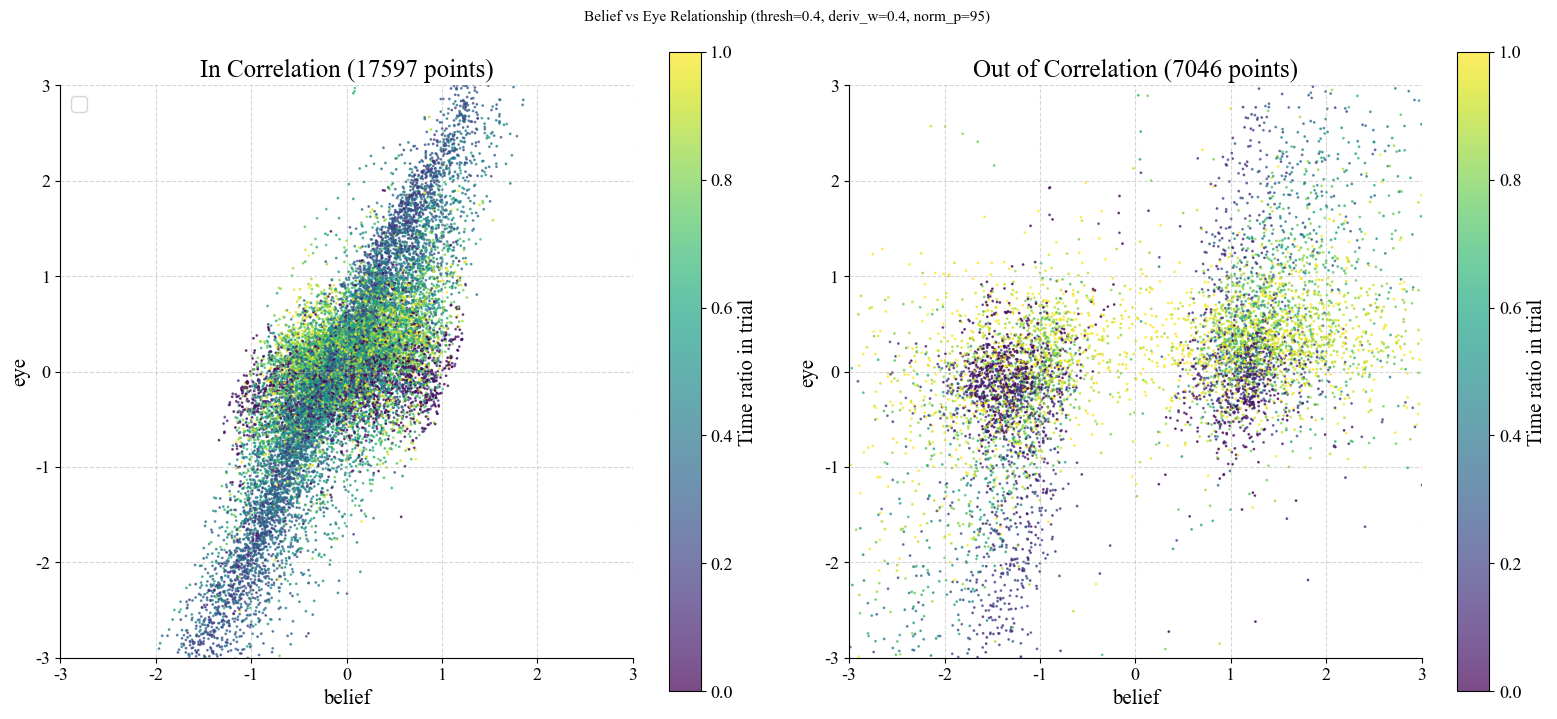

Total points: 24643
In correlation: 17597 (71.4%)
Out of correlation: 7046 (28.6%)
Threshold: 0.4, Derivative weight: 0.4
Normalization percentile: 95
(24643, 2) 24643


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


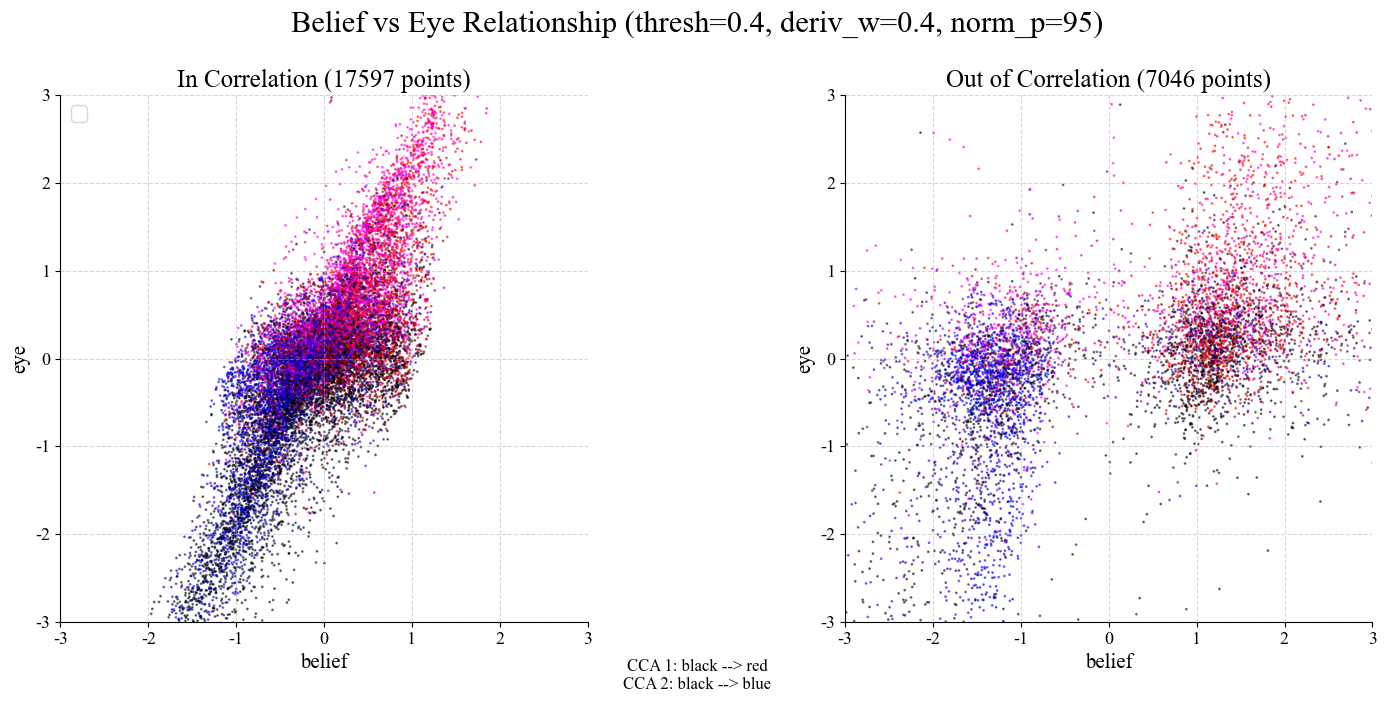

num data points 24643
in correlation: 17597 points (71.4%)
out of correlation: 7046 points (28.6%)


In [445]:
# For time ratio coloring
stats_time = plot_by_time_ratio(belief_arrays, eye_arrays, correlation_threshold=0.4, derivative_weight=0.4, 
                              normalization_percentile=95)

# For CCA coloring
stats_cca = plot_by_cca(belief_arrays, eye_arrays, neural_data, correlation_threshold=0.4, derivative_weight=0.4, 
                              normalization_percentile=95)

# old

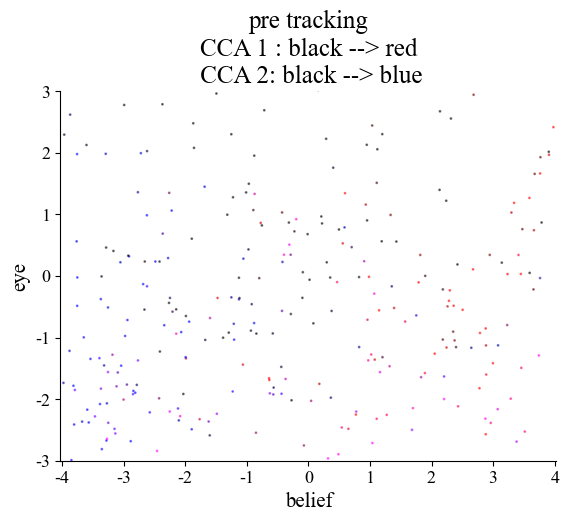

In [ ]:

# pre tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.2))]


neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)


    
thisx,thisy=related_taskvar[:,0], related_taskvar[:,1]
t1,t2=cca_neural[:,0],cca_neural[:,1]

c1=np.array([1,0,0])
c2=np.array([0,0,1])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.25
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('belief')
plt.ylabel('eye')
# plt.title('Scatter Plot with RGB Colors')
plt.axis('equal')
plt.xlim(-3,3)
plt.ylim(-3,3)
# plt.title(f'{session} PPC\nneural1 : black --> red\nneural 2: black --> blue')
plt.title(f'pre tracking\nCCA 1 : black --> red\n CCA 2: black --> blue')
plt.show()



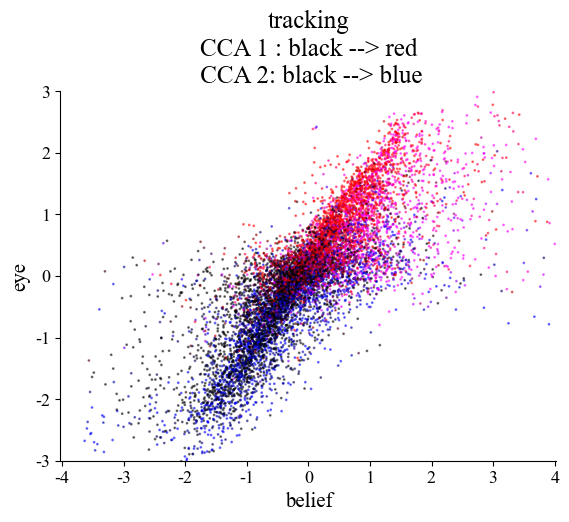

num data points 9975


In [355]:

# tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)


    
thisx,thisy=related_taskvar[:,0], related_taskvar[:,1]
t1,t2=cca_neural[:,0],cca_neural[:,1]

c1=np.array([1,0,0])
c2=np.array([0,0,1])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.25
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('belief')
plt.ylabel('eye')
# plt.title('Scatter Plot with RGB Colors')
plt.axis('equal')
plt.xlim(-3,3)
plt.ylim(-3,3)
# plt.title(f'{session} PPC\nneural1 : black --> red\nneural 2: black --> blue')
plt.title(f'tracking\nCCA 1 : black --> red\n CCA 2: black --> blue')
plt.show()
print('num data points',len(thisx))



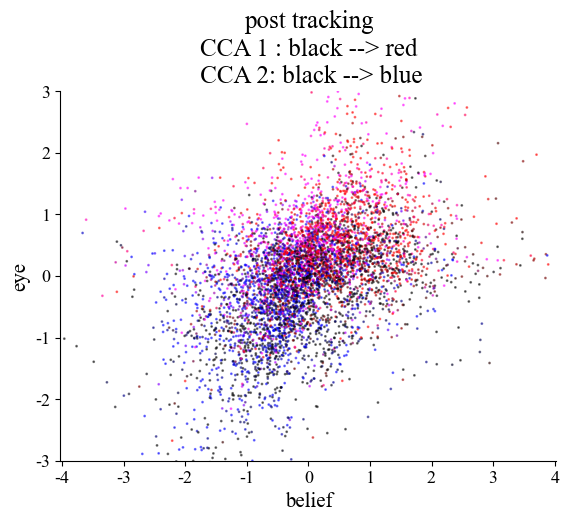

In [60]:

# post tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)


    
thisx,thisy=related_taskvar[:,0], related_taskvar[:,1]
t1,t2=cca_neural[:,0],cca_neural[:,1]

c1=np.array([1,0,0])
c2=np.array([0,0,1])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.25
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('belief')
plt.ylabel('eye')
# plt.title('Scatter Plot with RGB Colors')
plt.axis('equal')
plt.xlim(-3,3)
plt.ylim(-3,3)
# plt.title(f'{session} PPC\nneural1 : black --> red\nneural 2: black --> blue')
plt.title(f'post tracking\nCCA 1 : black --> red\n CCA 2: black --> blue')
plt.show()



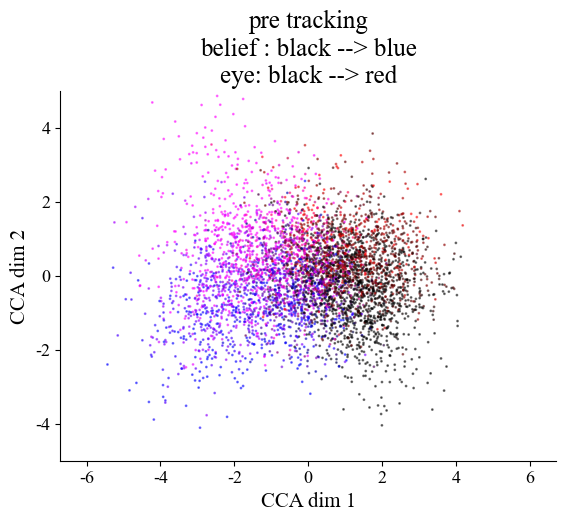

In [61]:
# pre tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.2))]


neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T


cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)

thisx,thisy=cca_neural[:,0],cca_neural[:,1]
t1,t2=related_taskvar[:,0], related_taskvar[:,1]
c1=np.array([0,0,1])
c2=np.array([1,0,0])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.3
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('CCA dim 1')
plt.ylabel('CCA dim 2')
plt.axis('equal')
plt.xlim(-5,5)
plt.ylim(-5,5) 
# plt.title(f'{session} PPC\nbelief : black --> blue\neye: black --> red')
plt.title(f'pre tracking\nbelief : black --> blue\neye: black --> red')
plt.show()

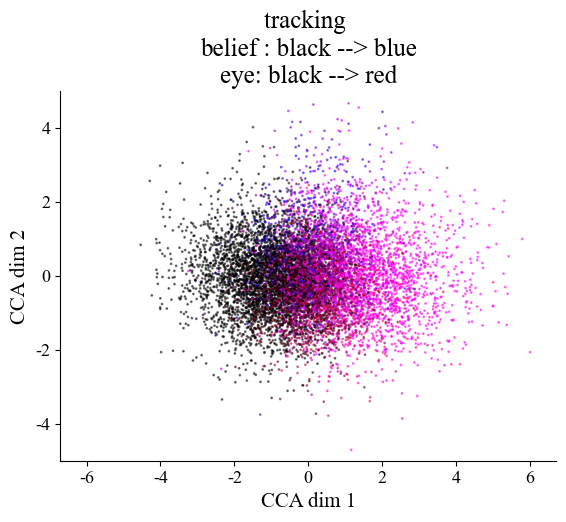

In [62]:

# tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]


neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T


cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)

thisx,thisy=cca_neural[:,0],cca_neural[:,1]
t1,t2=related_taskvar[:,0], related_taskvar[:,1]
c1=np.array([0,0,1])
c2=np.array([1,0,0])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.3
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('CCA dim 1')
plt.ylabel('CCA dim 2')
plt.axis('equal')
plt.xlim(-5,5)
plt.ylim(-5,5) 
# plt.title(f'{session} PPC\nbelief : black --> blue\neye: black --> red')
plt.title(f'tracking \nbelief : black --> blue\neye: black --> red')
plt.show()

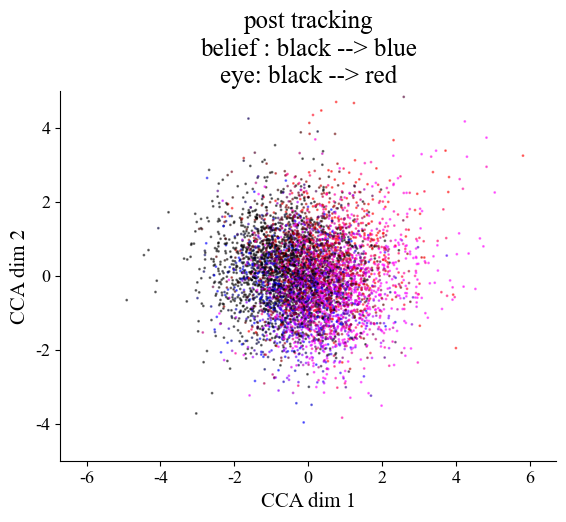

In [63]:

# post tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)

thisx,thisy=cca_neural[:,0],cca_neural[:,1]
t1,t2=related_taskvar[:,0], related_taskvar[:,1]
c1=np.array([0,0,1])
c2=np.array([1,0,0])
rgb_values=np.zeros((len(t1), 3))
rgb_values[:,[0,2]]=0.3
# rgb_values.shape, c1.shape, t1.shape
rgb_values+=(c1[:, None]*t1).T
rgb_values+=(c2[:, None]*t2).T

rgb_values=(rgb_values)
rgb_values=rgb_values.clip(0,1)
hex_colors = [mcolors.rgb2hex(color) for color in rgb_values]
plt.scatter(thisx, thisy, c=hex_colors,s=1, alpha=0.5)
# quickallspine(plt.gca())
plt.xlabel('CCA dim 1')
plt.ylabel('CCA dim 2')
plt.axis('equal')
plt.xlim(-5,5)
plt.ylim(-5,5) 
# plt.title(f'{session} PPC\nbelief : black --> blue\neye: black --> red')
plt.title(f'post tracking\nbelief : black --> blue\neye: black --> red')
plt.show()

In [64]:
thisdf=timedf[(timedf.fullon==0)]

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]


cca = CCA(n_components=2)
cca_neural, cca_be=cca.fit_transform(neural_data, related_taskvar)


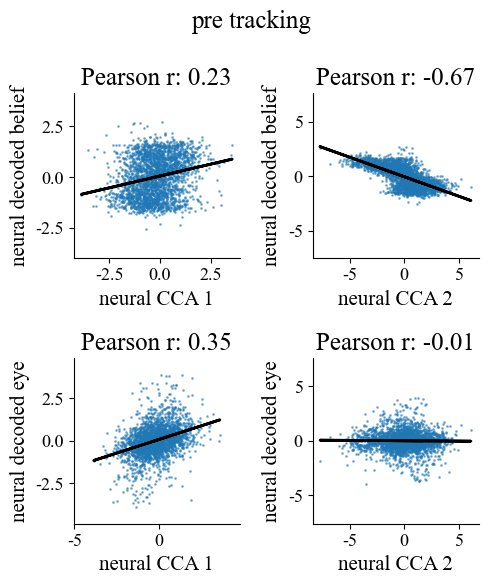

In [65]:

# pre tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<.1))]
condition='pre tracking'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]


model = LinearRegression()
model.fit(neural_data, related_taskvar)

# cca = CCA(n_components=2)
cca_neural, cca_be=cca.transform(neural_data, related_taskvar)


fig, axs = plt.subplots(2,2, figsize=(5,6))
ax=axs[0,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[0,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[1,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

ax=axs[1,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

plt.suptitle(f'{condition}')
plt.tight_layout()



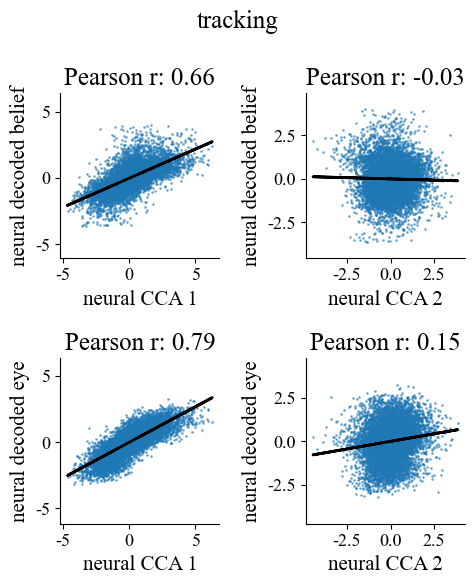

In [66]:

# tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7)&(timedf.timeratio>0.2))]
condition='tracking'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]


model = LinearRegression()
model.fit(neural_data, related_taskvar)

cca_neural, cca_be=cca.transform(neural_data, related_taskvar)


fig, axs = plt.subplots(2,2, figsize=(5,6))
ax=axs[0,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[0,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[1,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

ax=axs[1,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')


plt.suptitle(f'{condition}')
plt.tight_layout()



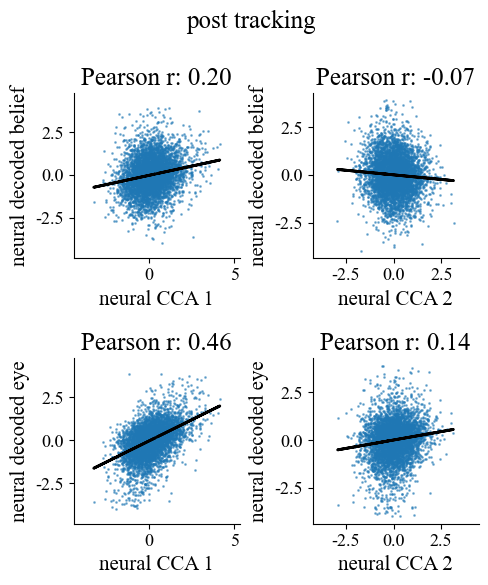

In [67]:

# post tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio>0.7))]
condition='post tracking'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]


model = LinearRegression()
model.fit(neural_data, related_taskvar)

cca_neural, cca_be=cca.transform(neural_data, related_taskvar)


fig, axs = plt.subplots(2,2, figsize=(5,6))
ax=axs[0,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[0,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[1,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

ax=axs[1,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

plt.suptitle(f'{condition}')
plt.tight_layout()



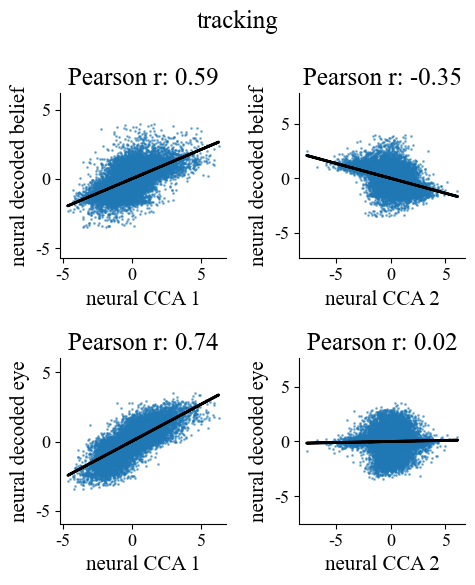

In [68]:

#  tracking 
thisdf=timedf[(timedf.fullon==0)&((timedf.timeratio<0.7))]
condition='tracking'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]


model = LinearRegression()
model.fit(neural_data, related_taskvar)

cca_neural, cca_be=cca.transform(neural_data, related_taskvar)


fig, axs = plt.subplots(2,2, figsize=(5,6))
ax=axs[0,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[0,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,0]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded belief')
ax.axis('equal')

ax=axs[1,0]
thisx,thisy=cca_neural[:,0],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 1')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

ax=axs[1,1]
thisx,thisy=cca_neural[:,1],related_taskvar[:,1]
plot_best_fit(thisx, thisy, ax)
r,_=pearsonr(thisx, thisy)
ax.set_title(f'Pearson r: {r:.2f}')
ax.scatter(thisx, thisy,s=1, alpha=0.5)
ax.set_xlabel('neural CCA 2')
ax.set_ylabel('neural decoded eye')
ax.axis('equal')

plt.suptitle(f'{condition}')
plt.tight_layout()

